In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from common import get_triads,get_G
import matplotlib.animation as animation
%config InlineBackend.figure_format='retina'

In [2]:
kmax=30;kmin=6
n=int(kmax)*2+1
idk=(np.array(np.where(np.zeros([n]*2)==0))-kmax).astype(int)
order=lambda x: ((x[0]+kmax)*n+(x[1]+kmax)).astype(int)

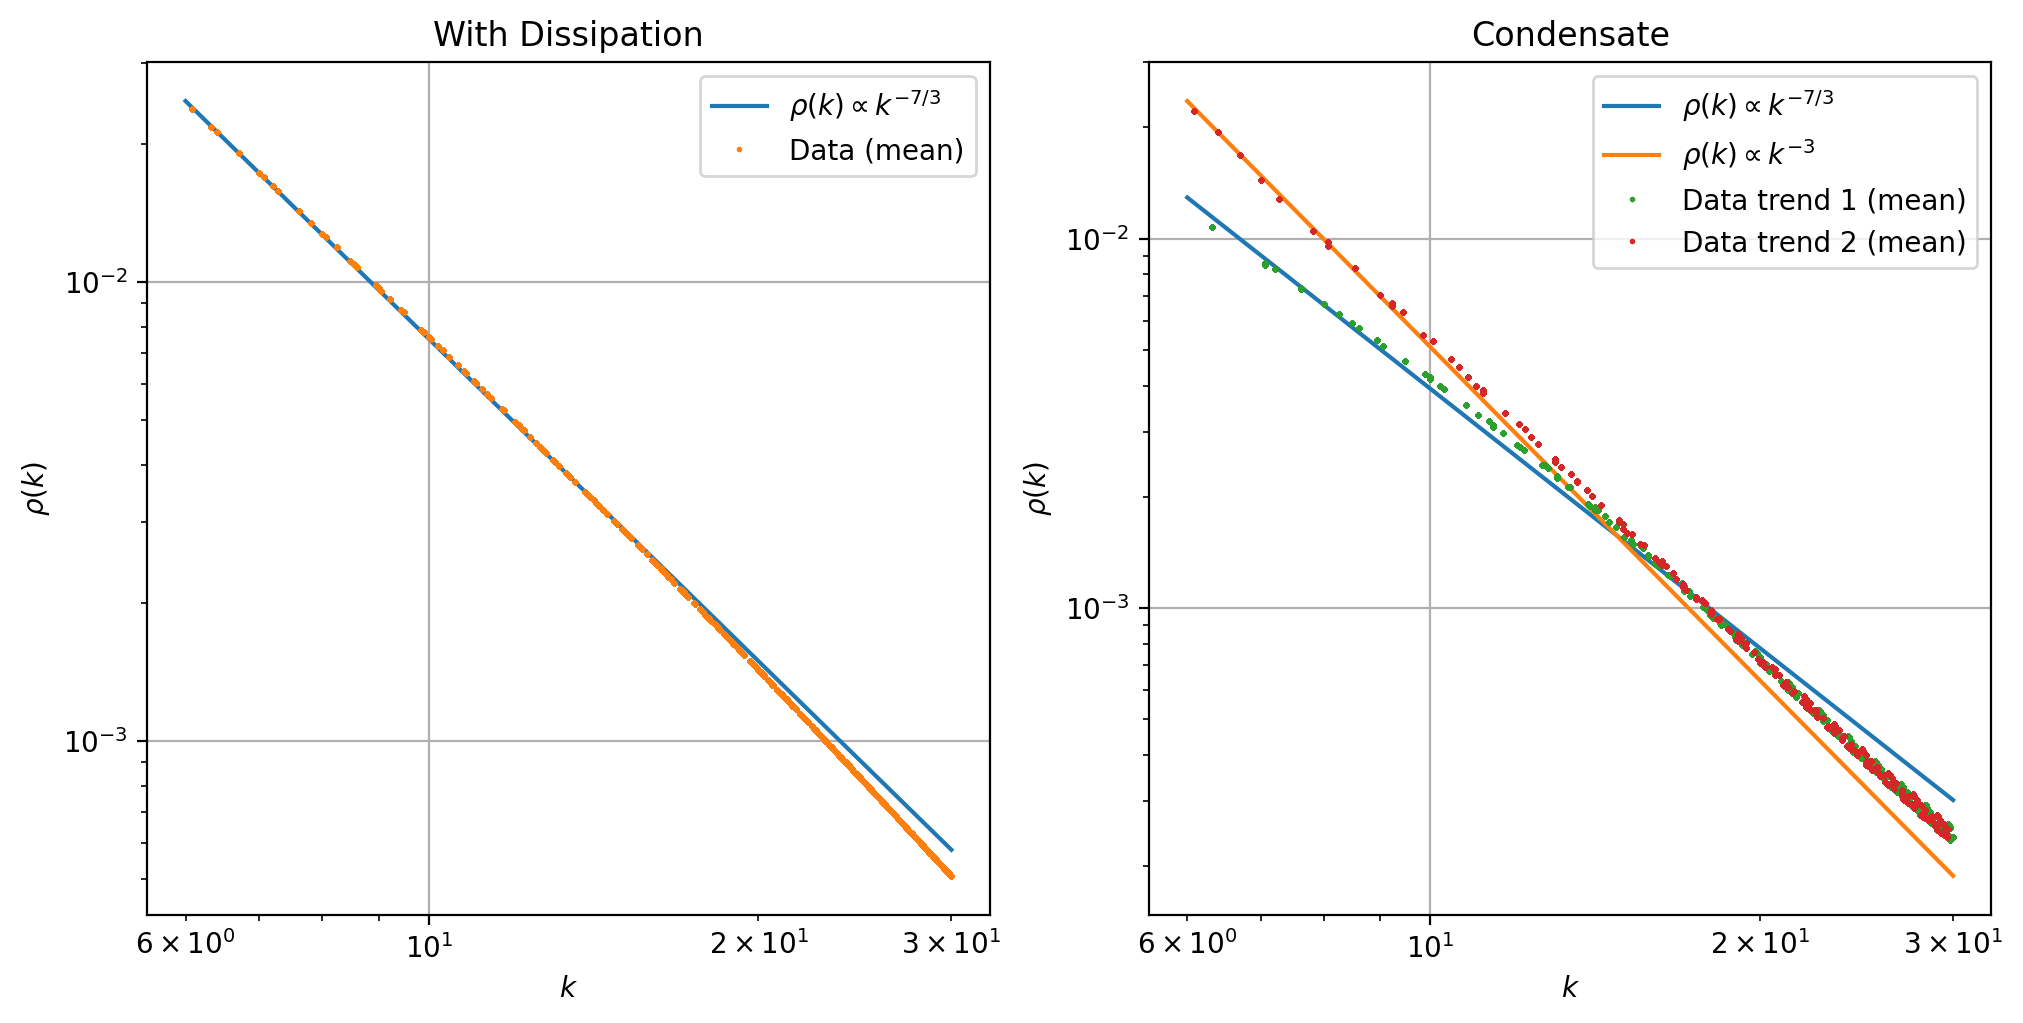

In [3]:
%matplotlib inline

path='./data/regular_2D/'
triads=np.loadtxt(path+'triads.txt')
thetauuu=np.load(path+'thetauuu.npy').astype(np.float64)
rhok_d=np.load(path+'rhok.npy').astype(np.float64);rhop_d=np.load(path+'rhop.npy').astype(np.float64);rhoq_d=np.load(path+'rhoq.npy').astype(np.float64)
k_d=triads[:,[0,1]].T
p_d=triads[:,[2,3]].T
q_d=-k_d-p_d
k_d=np.column_stack((k_d,p_d,q_d))
rhok_d=np.column_stack((rhok_d,rhop_d,rhoq_d))[0]
kmag_d=np.linalg.norm(k_d,axis=0)

def rho_fit_1(x,a):
    return a*(x**(-7/3))
def rho_fit_2(x,a):
    return a*(x**(-3))

fig,ax=plt.subplots(1,2,layout='constrained',figsize=(10,5))
a0=curve_fit(rho_fit_1,kmag_d,rhok_d)[0]
ax[0].loglog(np.linspace(6,30),rho_fit_1(np.linspace(6,30),a0),label=r'$\rho(k)\propto k^{-7/3}$')
ax[0].plot(kmag_d,rhok_d,'.',ms=2,label=r'Data (mean)')
ax[0].set_xlabel(r'$k$');ax[0].set_ylabel(r'$\rho(k)$');ax[0].set_title('With Dissipation')
ax[0].grid();ax[0].legend()

path='./data/condensate/'
triads=np.loadtxt(path+'triads.txt')
thetauuu=np.load(path+'thetauuu.npy').astype(np.float64)
rhok_d=np.load(path+'rhok.npy').astype(np.float64);rhop_d=np.load(path+'rhop.npy').astype(np.float64);rhoq_d=np.load(path+'rhoq.npy').astype(np.float64)
k_d=triads[:,[0,1]].T
p_d=triads[:,[2,3]].T
q_d=-k_d-p_d
k_d=np.column_stack((k_d,p_d,q_d))
rhok_d=np.column_stack((rhok_d,rhop_d,rhoq_d))[0]
kmag_d=np.linalg.norm(k_d,axis=0)

a1=curve_fit(rho_fit_1,kmag_d[order(k_d)%2==0],rhok_d[order(k_d)%2==0])[0]
a2=curve_fit(rho_fit_2,kmag_d[order(k_d)%2==1],rhok_d[order(k_d)%2==1])[0]

ax[1].loglog(np.linspace(6,30),rho_fit_1(np.linspace(6,30),a1),label=r'$\rho(k)\propto k^{-7/3}$')
ax[1].plot(np.linspace(6,30),rho_fit_2(np.linspace(6,30),a2),label=r'$\rho(k)\propto k^{-3}$')
# ax[1].plot(kmag_d,rhok_d,'.',ms=2,label=r'Data (mean)')
ax[1].plot(kmag_d[order(k_d)%2==0],rhok_d[order(k_d)%2==0],'.',ms=2,label=r'Data trend 1 (mean)')
ax[1].plot(kmag_d[order(k_d)%2==1],rhok_d[order(k_d)%2==1],'.',ms=2,label=r'Data trend 2 (mean)')
ax[1].set_xlabel(r'$k$');ax[1].set_ylabel(r'$\rho(k)$');ax[1].set_title('Condensate')
ax[1].grid();ax[1].legend()

plt.show()

In [4]:
def get_cos_term(kmax=30,kmin=6,rho=lambda x:x**(-7/3)):
    n=int(kmax)*2+1
    idk=(np.array(np.where(np.zeros([n]*2)==0))-kmax).astype(int)
    order=lambda x: ((x[0]+kmax)*n+(x[1]+kmax)).astype(int)
    k,p,q,kmag,pmag,qmag=get_triads(duplicates=True,kmax=kmax,kmin=kmin)
    rhok=rho(kmag);rhop=rho(pmag);rhoq=rho(qmag)

    K=((qmag**2-pmag**2)*kmag**-2*(rhop*rhoq)**2)+((pmag**2-kmag**2)*qmag**-2*(rhop*rhok)**2)+((kmag**2-qmag**2)*pmag**-2*(rhok*rhoq)**2)
    D=np.sqrt(pmag**2+qmag**2)
    C=-np.cross(q,p,axis=0)/(rhok*rhop*rhoq)*K

    just_cos=np.zeros([len(idk.T)]*2)
    just_cos[order(k),order(p)]=-C/(2*D)
    return just_cos

In [5]:
rho0=lambda x: a0*(x**(-7/3))
rho1=lambda x: a1*(x**(-7/3))
rho2=lambda x: a2*(x**(-3))
# k,p,q,kmag,pmag,qmag,Gcosrho,Gcosrho_dir=get_G(return_triads=True,kmax=kmax,kmin=kmin,rho=rho0)
# _,Gcosrho_dir_con=get_G(return_triads=False,kmax=kmax,kmin=kmin,rho=rho2)

normal=get_cos_term(rho=rho0)
cond=get_cos_term(rho=rho2)

In [6]:
cos_terms=[]
for path in ['./data/regular_2D/','./data/condensate/']:
    triads=np.loadtxt(path+'triads.txt')
    thetauuu=np.load(path+'thetauuu.npy').astype(np.float64)
    rhok_d=np.load(path+'rhok.npy').astype(np.float64)[0];rhop_d=np.load(path+'rhop.npy').astype(np.float64)[0];rhoq_d=np.load(path+'rhoq.npy').astype(np.float64)[0]
    k_d=triads[:,[0,1]].T
    p_d=triads[:,[2,3]].T
    q_d=-k_d-p_d
    
    kmag_d=np.linalg.norm(k_d,axis=0);pmag_d=np.linalg.norm(p_d,axis=0);qmag_d=np.linalg.norm(q_d,axis=0)
    
    K=((qmag_d**2-pmag_d**2)*kmag_d**-2*(rhop_d*rhoq_d)**2)+((pmag_d**2-kmag_d**2)*qmag_d**-2*(rhop_d*rhok_d)**2)+((kmag_d**2-qmag_d**2)*pmag_d**-2*(rhok_d*rhoq_d)**2)
    D=np.sqrt(pmag_d**2+qmag_d**2)
    C=-np.cross(q_d,p_d,axis=0)/(rhok_d*rhop_d*rhoq_d)*K

    cos_term_est=np.zeros([len(idk.T)]*2)
    cos_term_est[order(k_d),order(p_d)]=-C/(2*D)
    
    Nbins=30;Ntriads=triads.shape[0];shape_uuu=(Nbins,Ntriads)
    dtheta=2*np.pi/Nbins
    thetaplt=-np.pi+dtheta/2+dtheta*np.arange(Nbins)
    thetadiff=np.diff(thetaplt)[0]
    theta_edges=np.concatenate([[thetaplt[0]-thetadiff/2],thetaplt+thetadiff/2])
    
    norm=np.trapz(thetauuu,x=thetaplt,axis=0)+dtheta*0.5*(thetauuu[0,:]+thetauuu[-1,:])
    norm[norm==0.0]=np.nan
    thetauuu*=norm**-1
    integrand=np.cos(thetaplt.reshape(Nbins,1))*thetauuu
    mean_sync=np.trapz(integrand,x=thetaplt.reshape(Nbins,1),axis=0)+dtheta*0.5*(integrand[0]+integrand[-1])
    
    dot_term=(k_d*p_d).sum(axis=0)
    rho_term=rhok_d*rhop_d*rhoq_d
    
    cos_term_data=np.zeros([len(idk.T)]*2)
    cos_term_data[order(k_d),order(p_d)]=mean_sync

    cos_terms.append(cos_term_est)
    cos_terms.append(cos_term_data)

In [7]:
%matplotlib inline

def theta_comparison(use_condensate=True,odd=False,radius=9):
    if use_condensate:
        data=cos_terms[2:]
        prediction=normal
    else:
        data=cos_terms[:2]
        prediction=cond
    prediction[data[1]==0]=0
    
    norms=np.linalg.norm(idk,axis=0)
    points=idk[:,norms.round()==radius]
    points=points.T[np.argsort(np.arctan2(points[1],points[0]))]
    coords=(idk+kmax).astype(int)
    
    for i in range(len(points)):
        if use_condensate:
            if order(points[i])%2==odd:
                continue
        
        fig,ax=plt.subplots(1,3,layout='constrained')
        ax[0].set_title(r'est $\theta$, data $\rho$')
        ax[1].set_title(r'data $\theta$, data $\rho$')
        ax[2].set_title(r'masked prediction')
        # for j in range(len(ax)): ax[j].set_axis_off()
            
        grid=np.zeros([n]*2);grid[coords[1],coords[0]]=data[0][order(points[i])]
        if np.all(grid==0):
            plt.close()
            continue
        grid[grid==0]=None
        vmax=np.percentile(np.abs(grid)[~np.isnan(grid)],95)
        ax[0].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='seismic',vmin=-vmax,vmax=vmax)
    
        grid=np.zeros([n]*2);grid[coords[1],coords[0]]=data[1][order(points[i])]
        if np.all(grid==0):
            plt.close()
            continue
        grid[grid==0]=None
        vmax=np.percentile(np.abs(grid)[~np.isnan(grid)],95)
        ax[1].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='seismic',vmin=-vmax,vmax=vmax)
    
        grid=np.zeros([n]*2);grid[coords[1],coords[0]]=prediction[order(points[i])]
        if np.all(grid==0):
            plt.close()
            continue
        grid[grid==0]=None
        vmax=np.percentile(np.abs(grid)[~np.isnan(grid)],95)
        ax[2].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='seismic',vmin=-vmax,vmax=vmax)
        
        plt.show()
        plt.close()

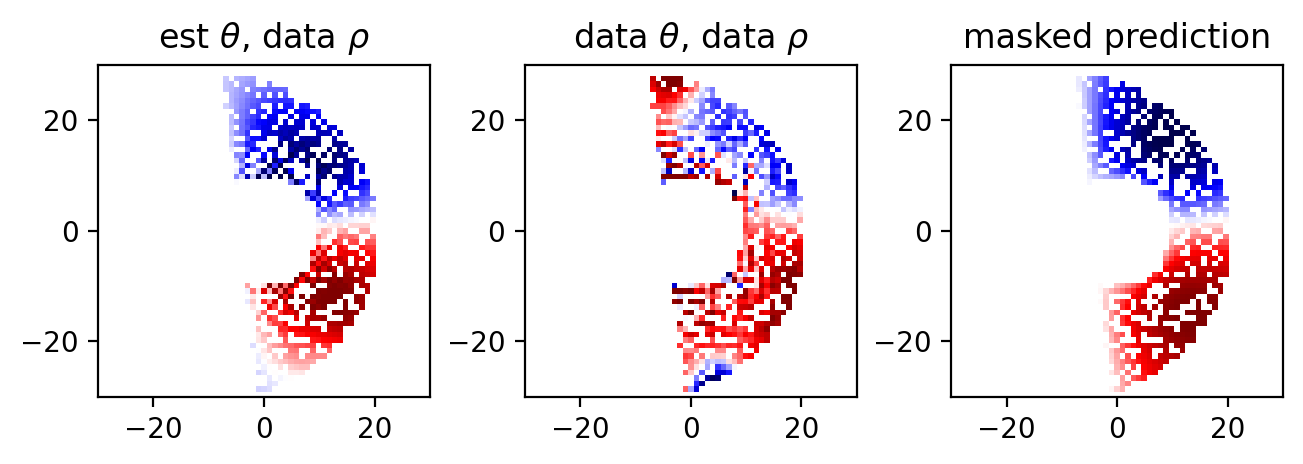

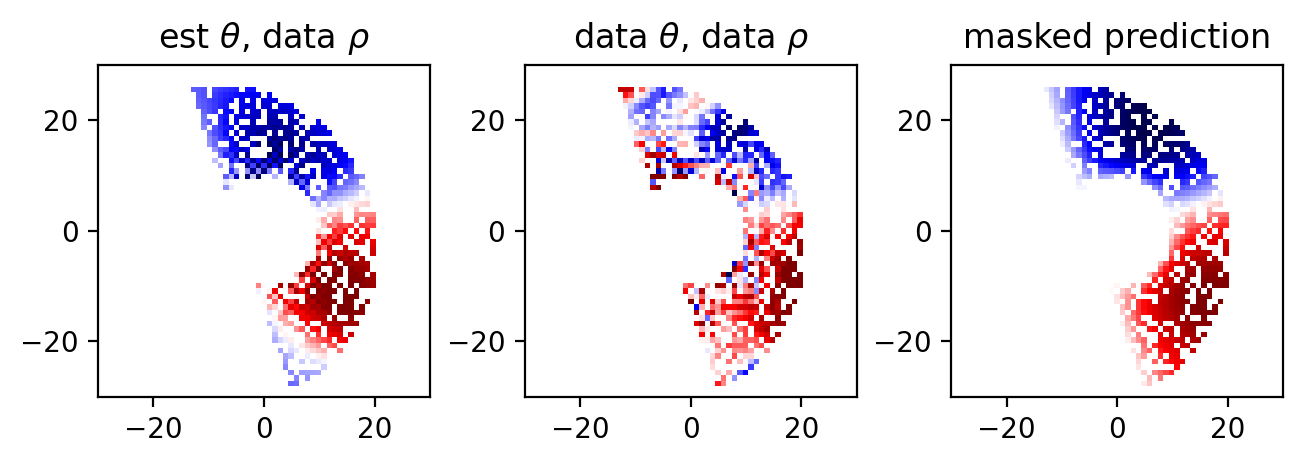

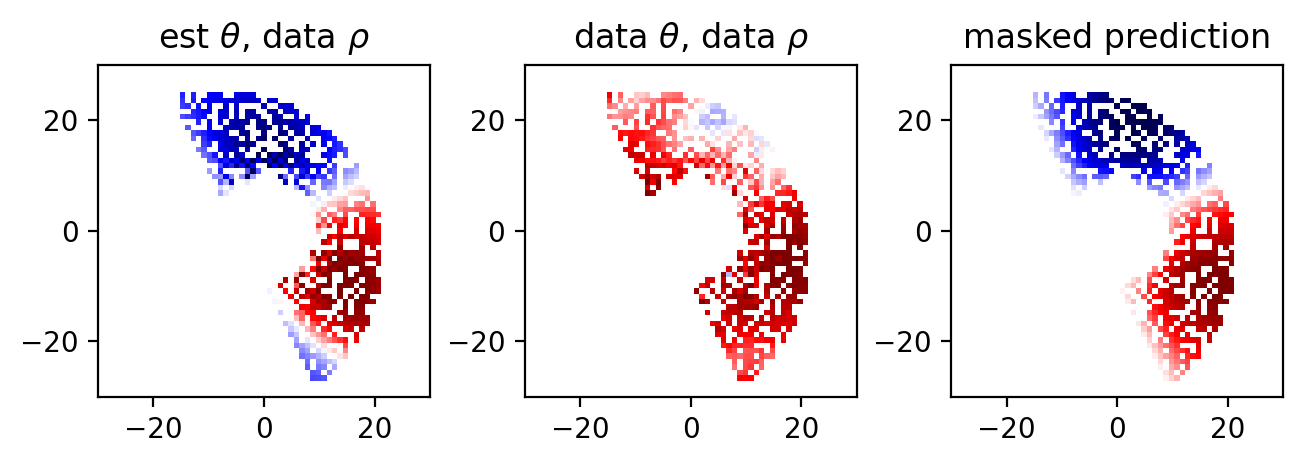

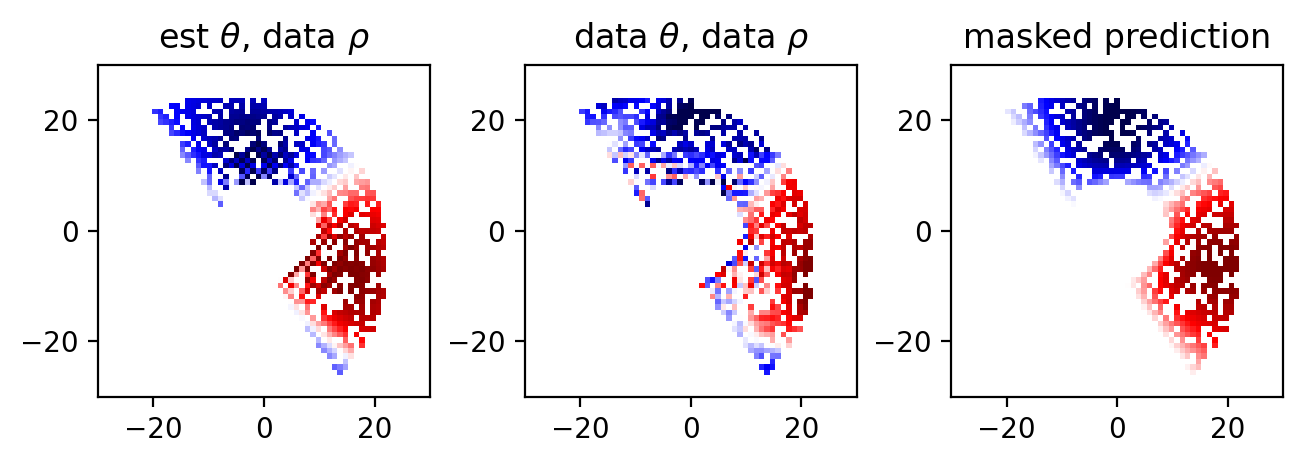

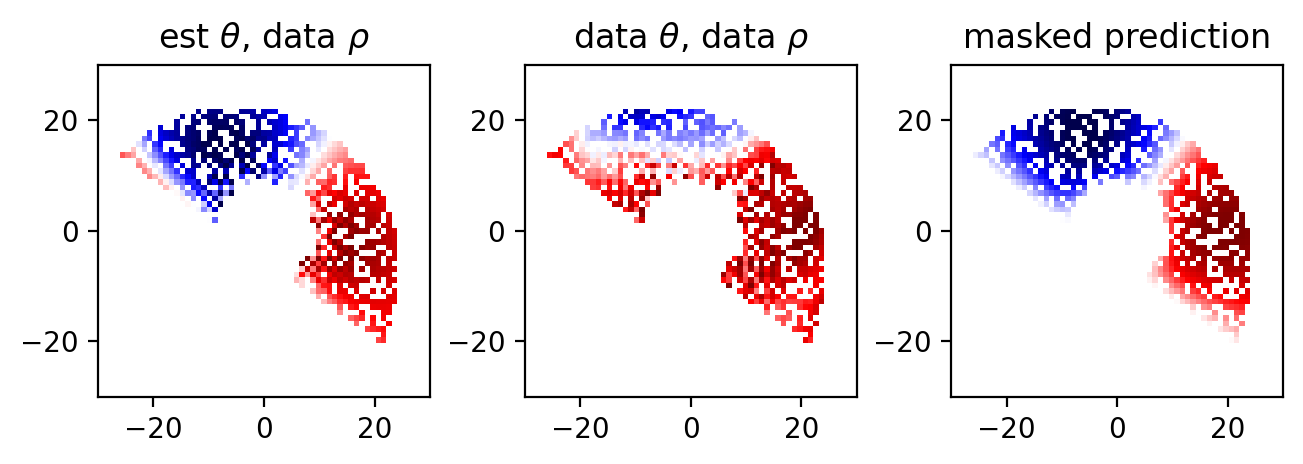

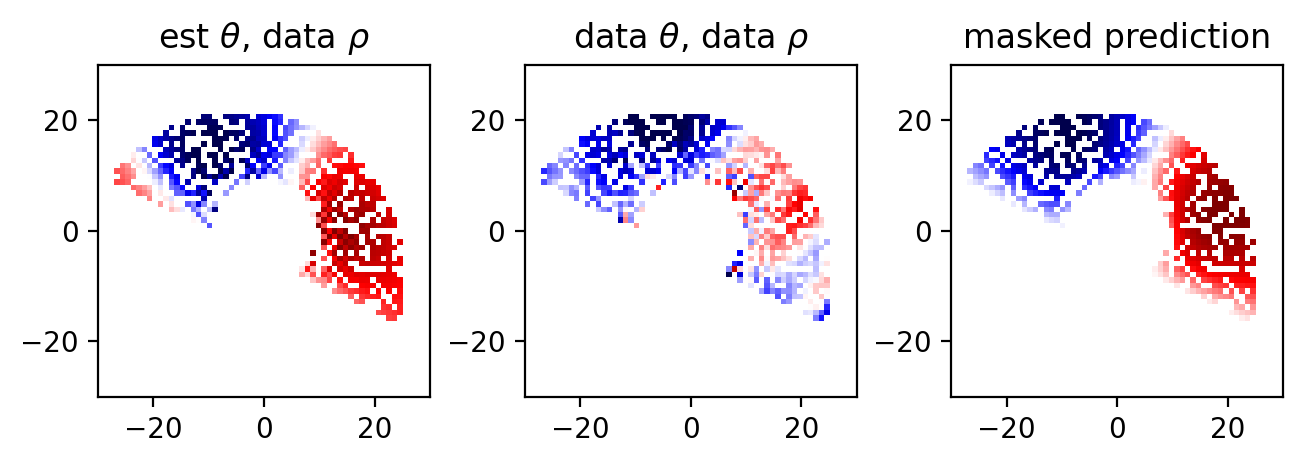

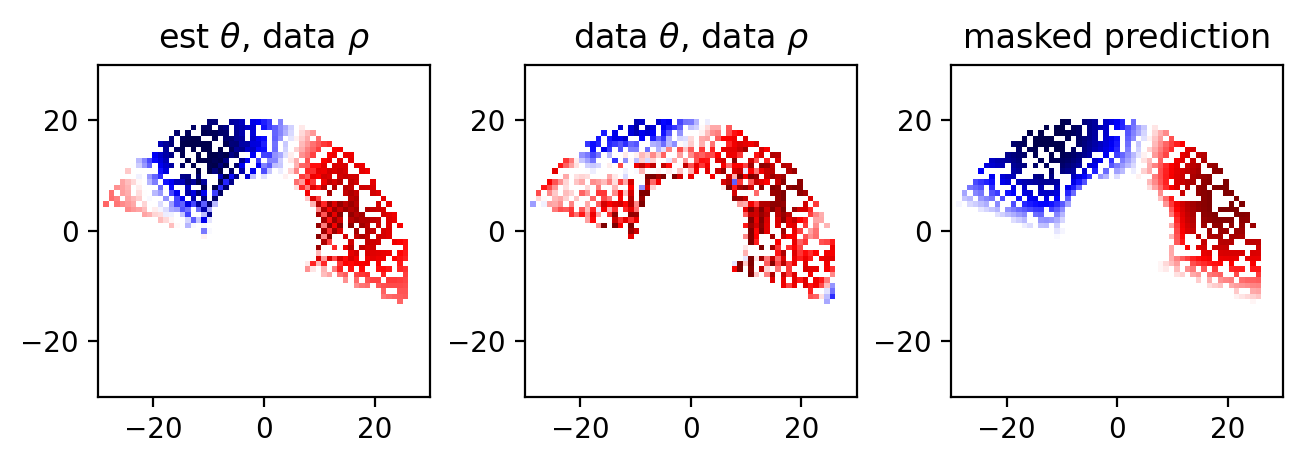

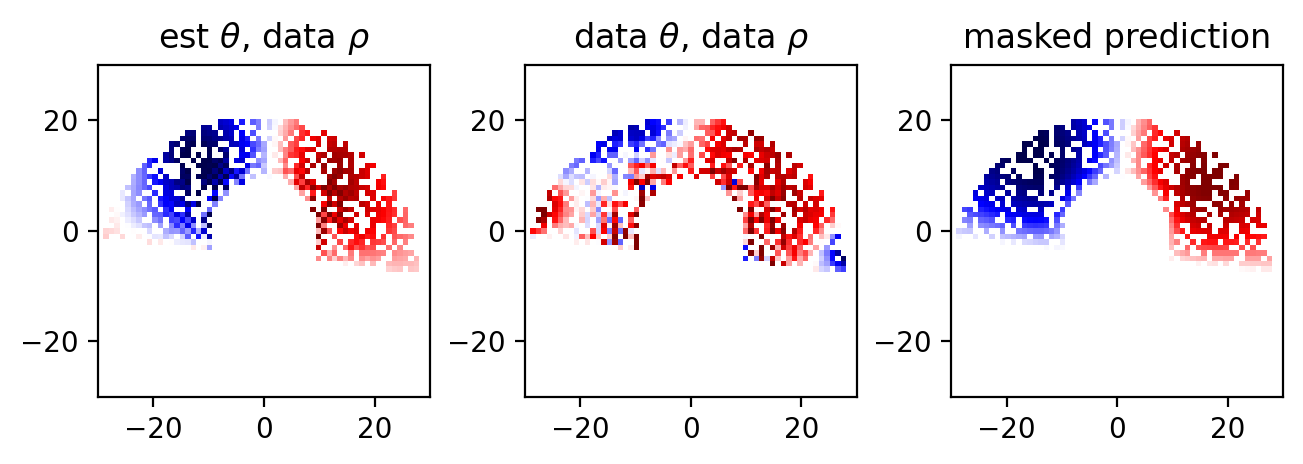

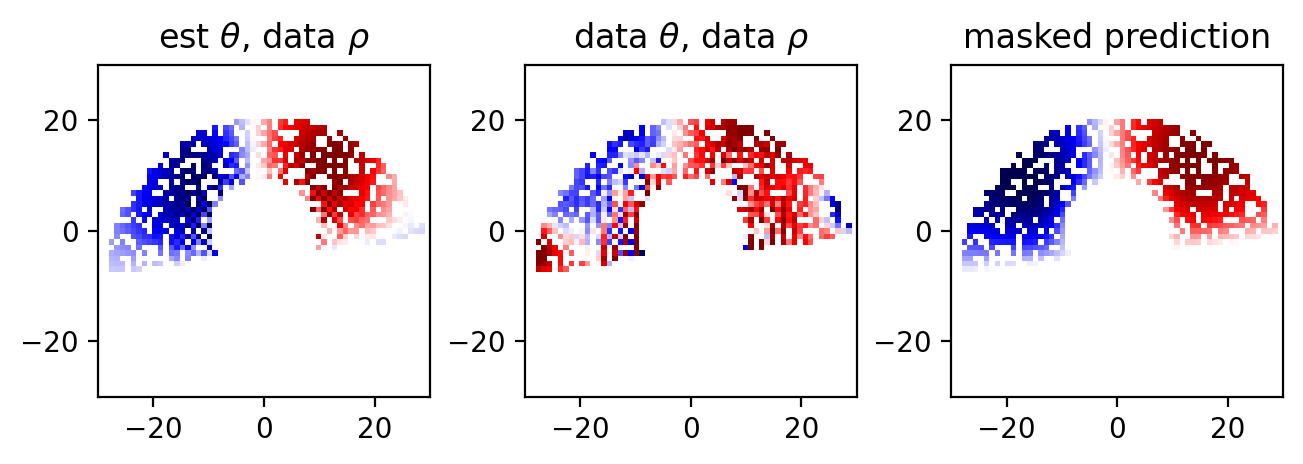

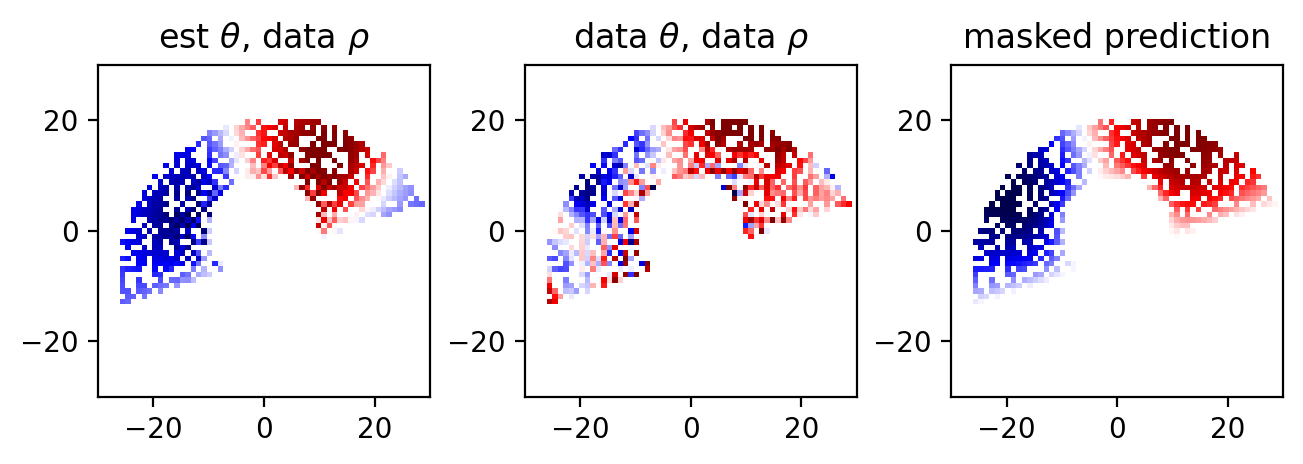

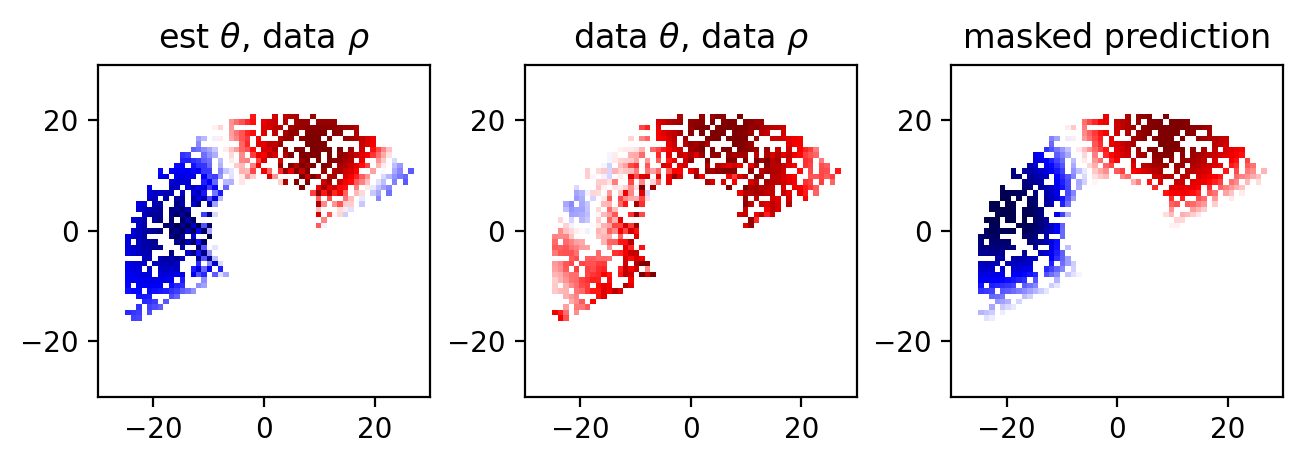

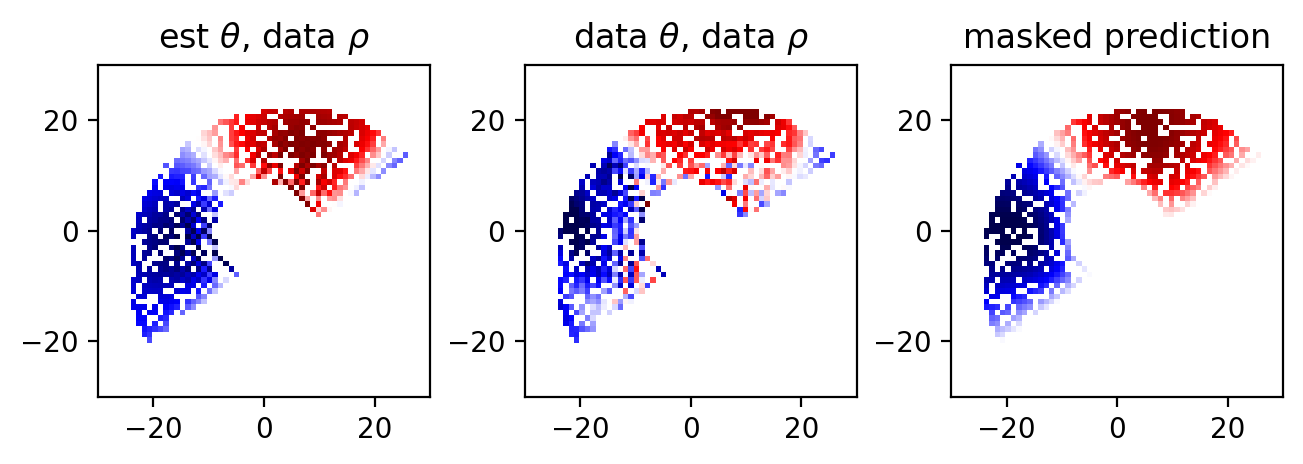

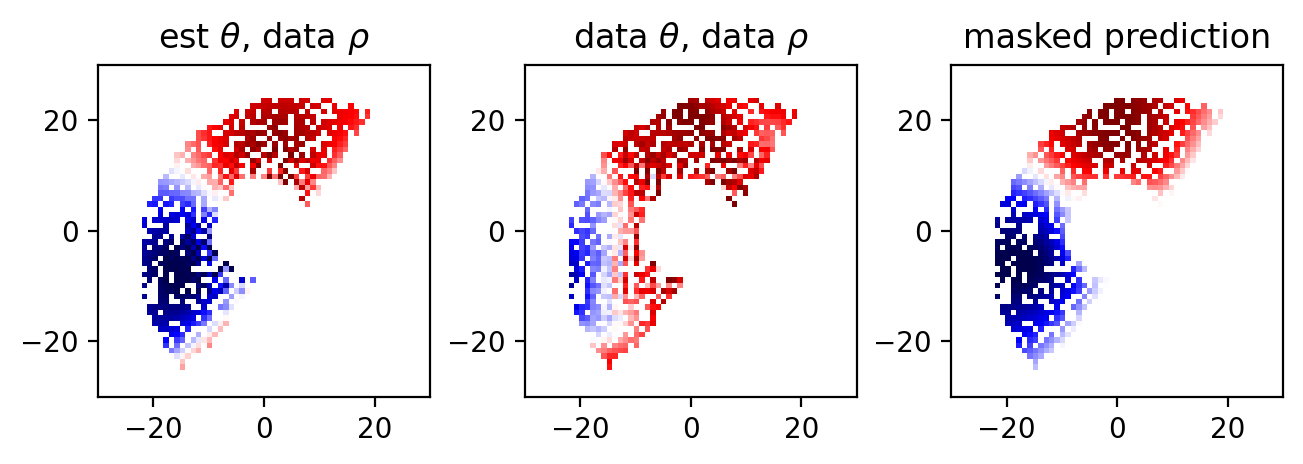

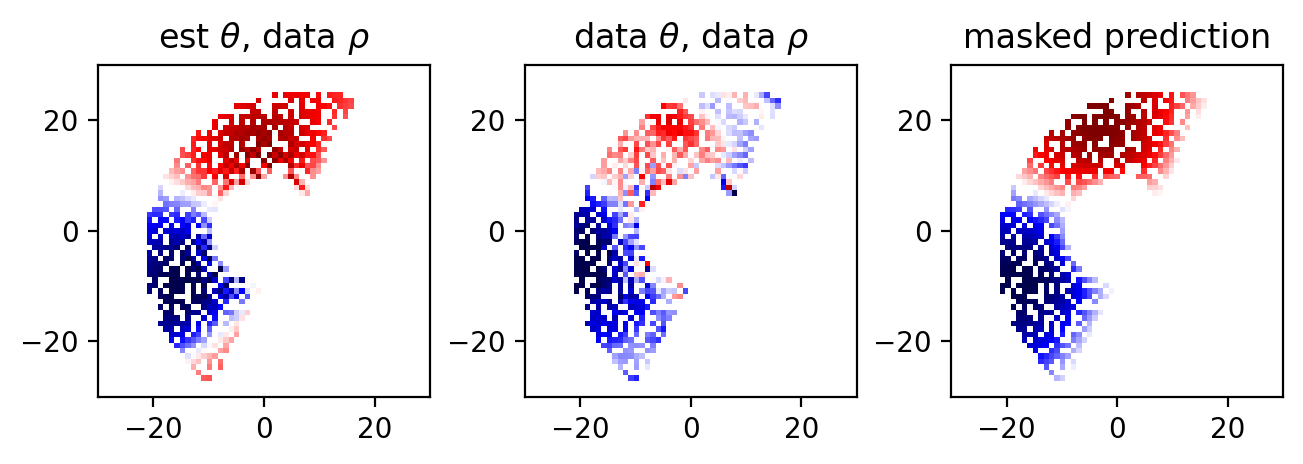

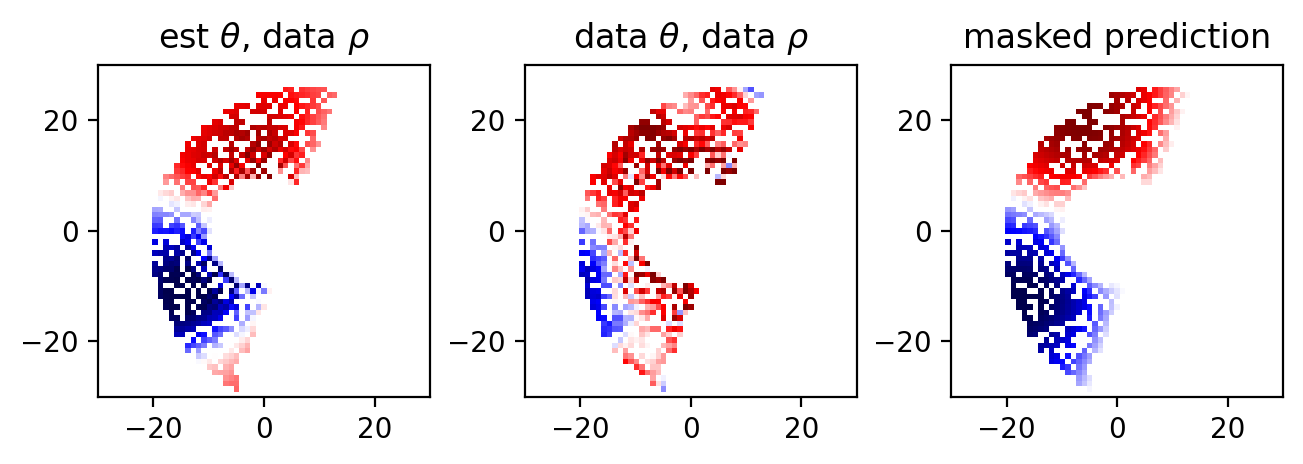

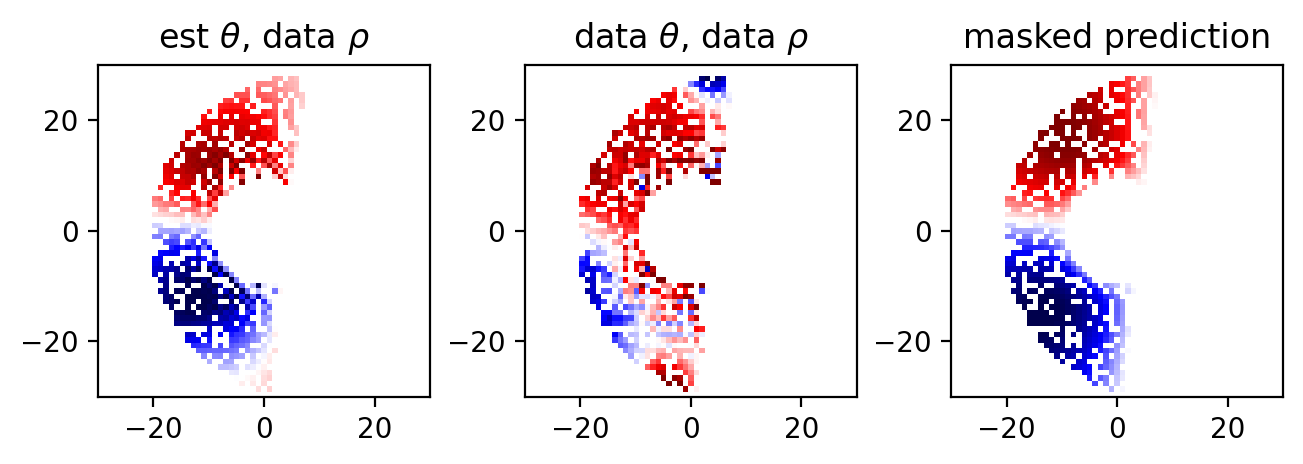

In [8]:
theta_comparison(use_condensate=True,odd=True)

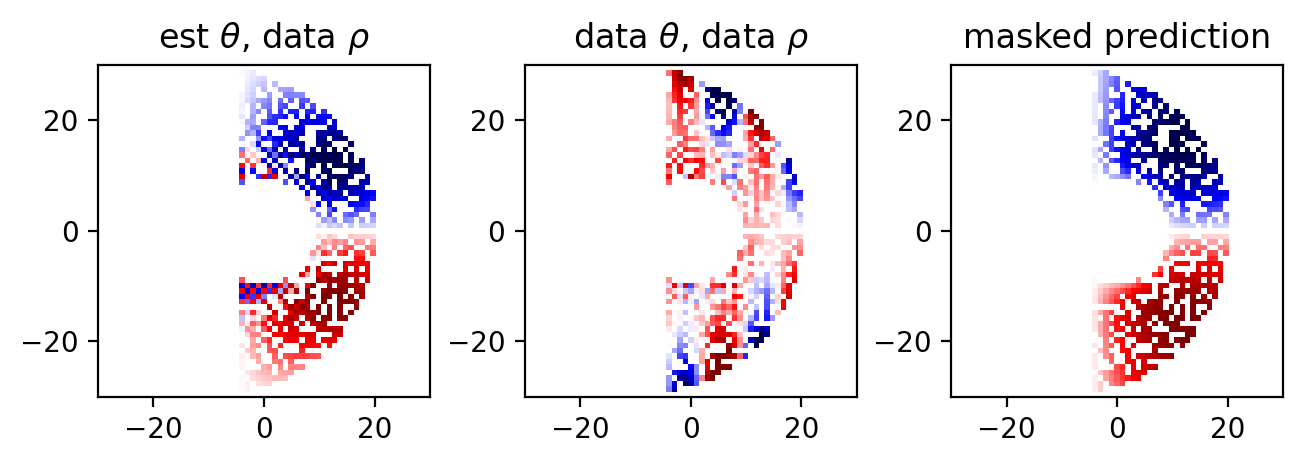

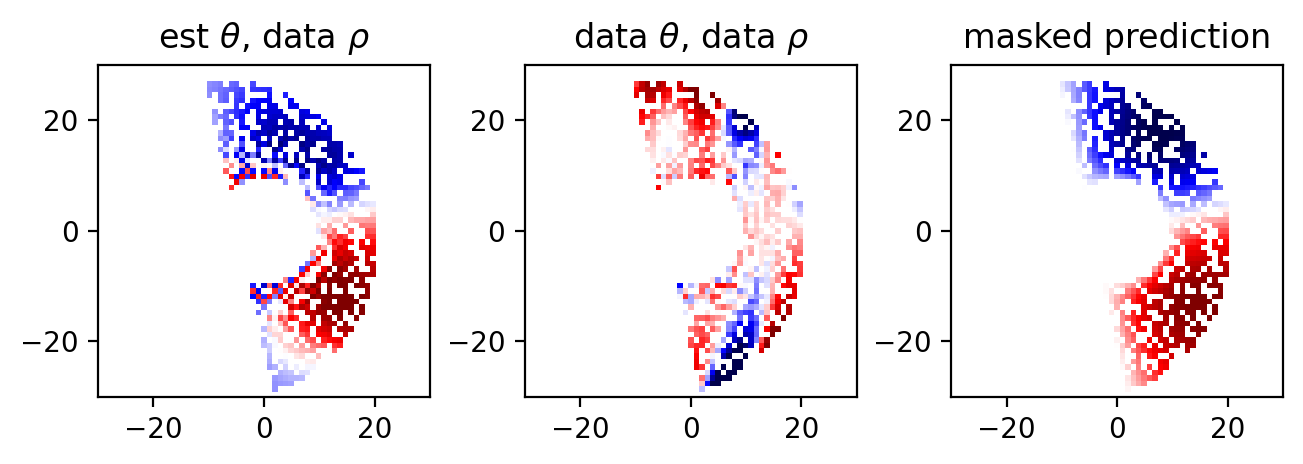

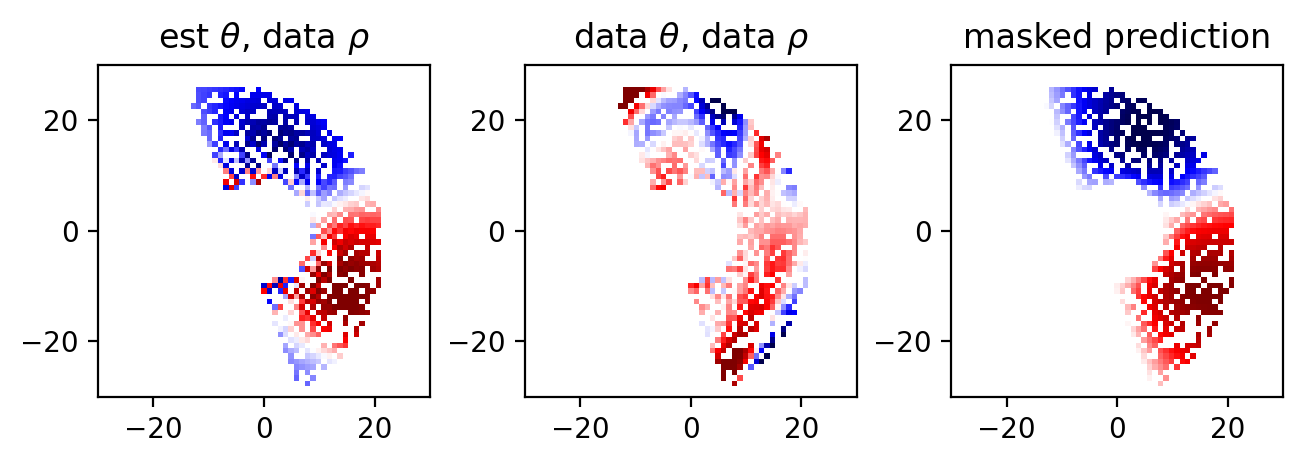

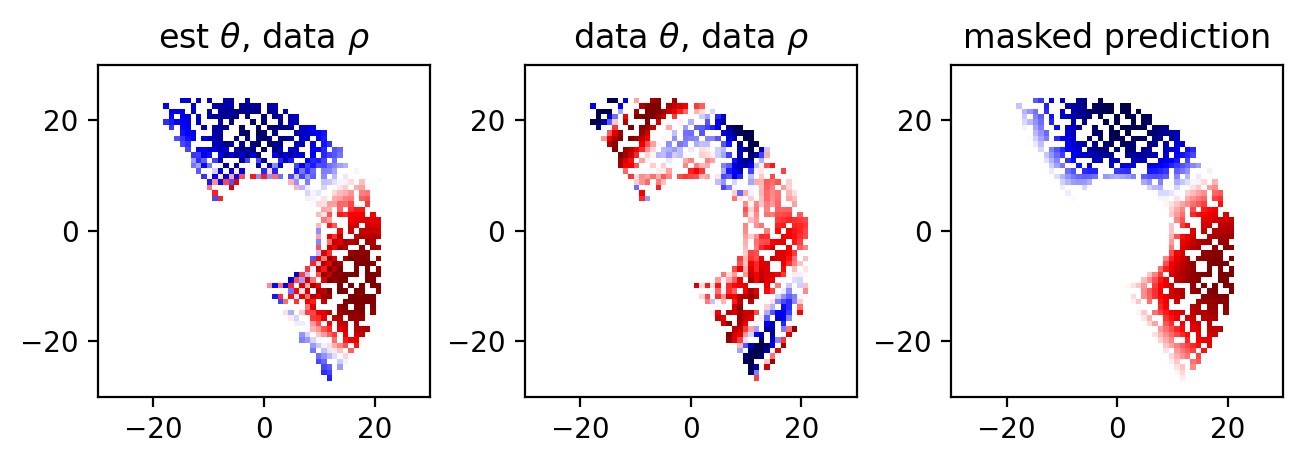

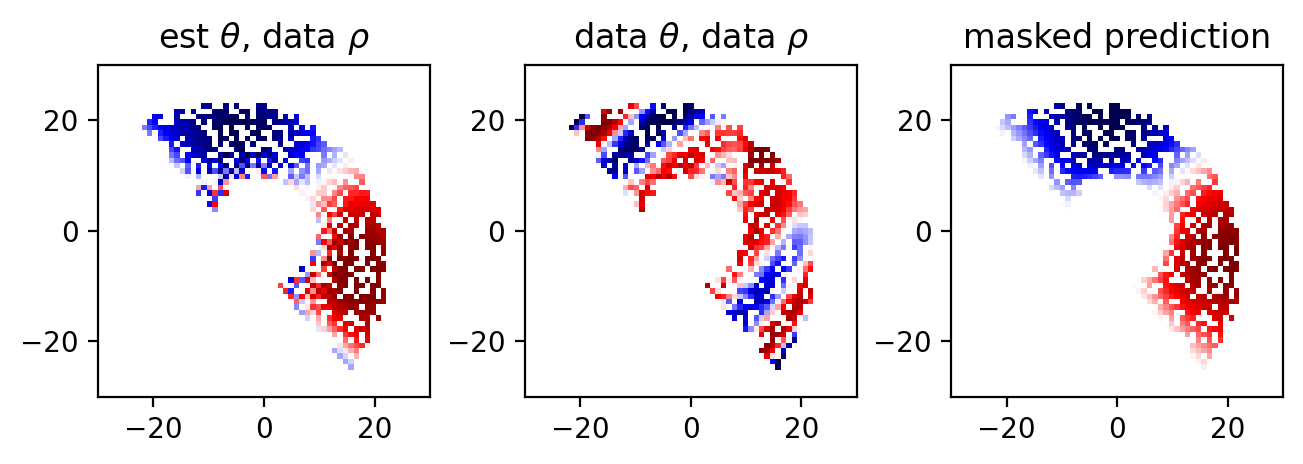

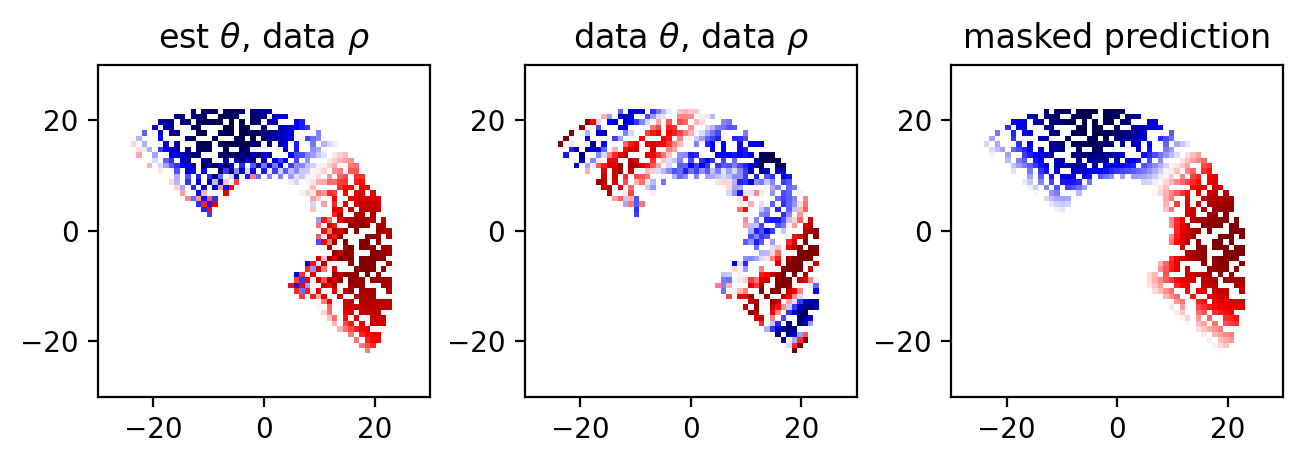

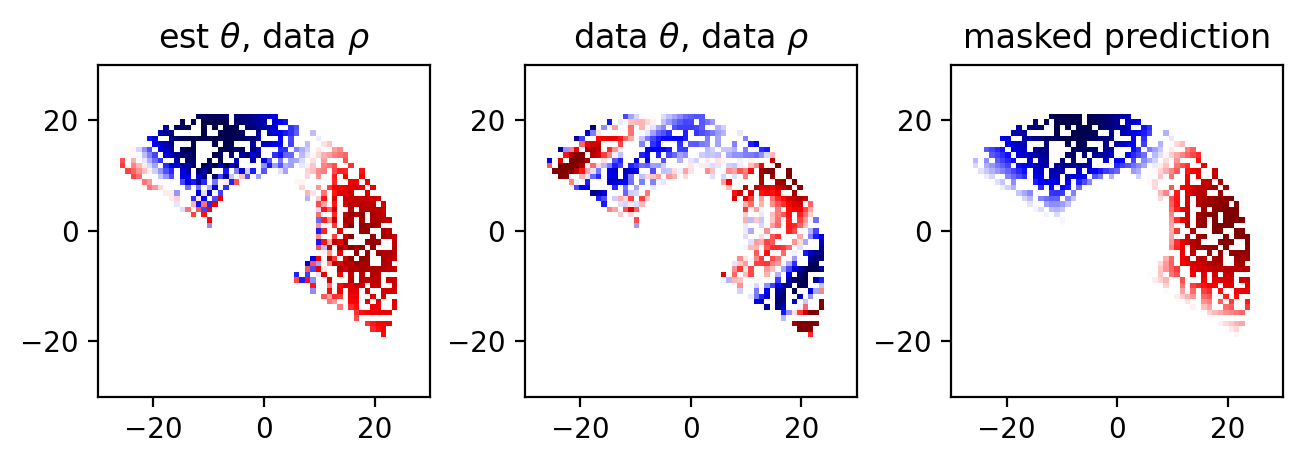

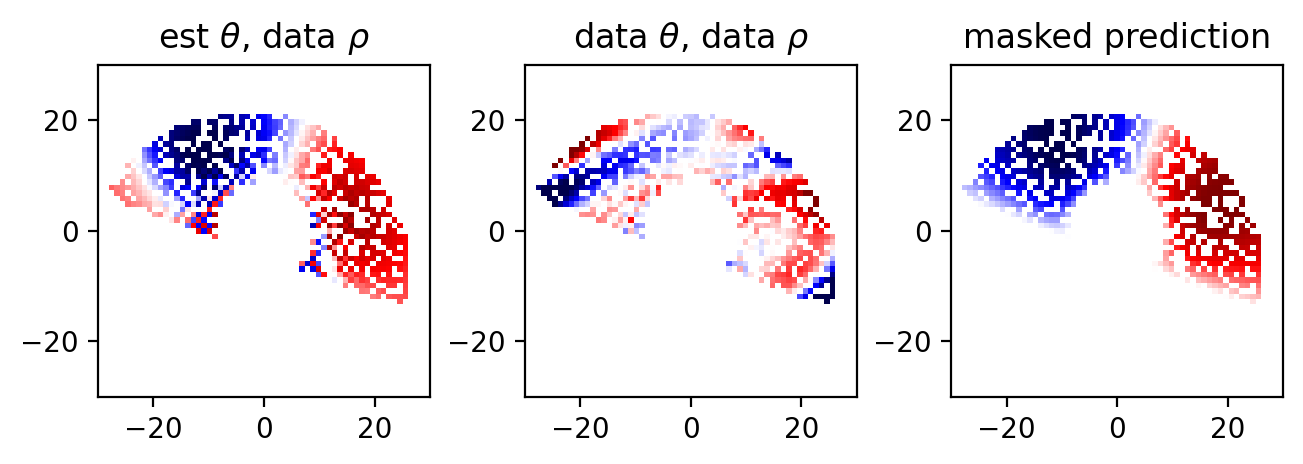

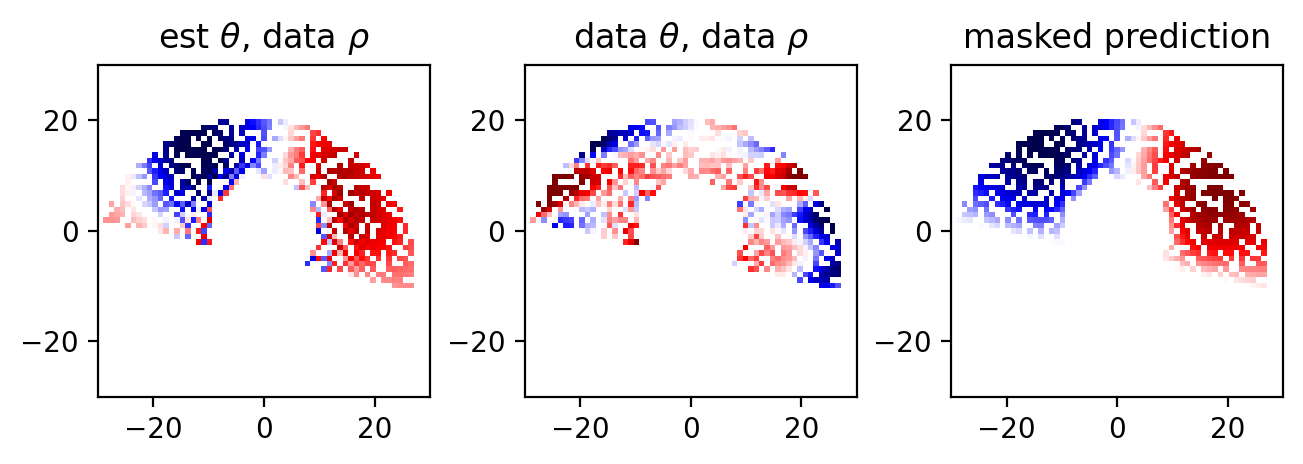

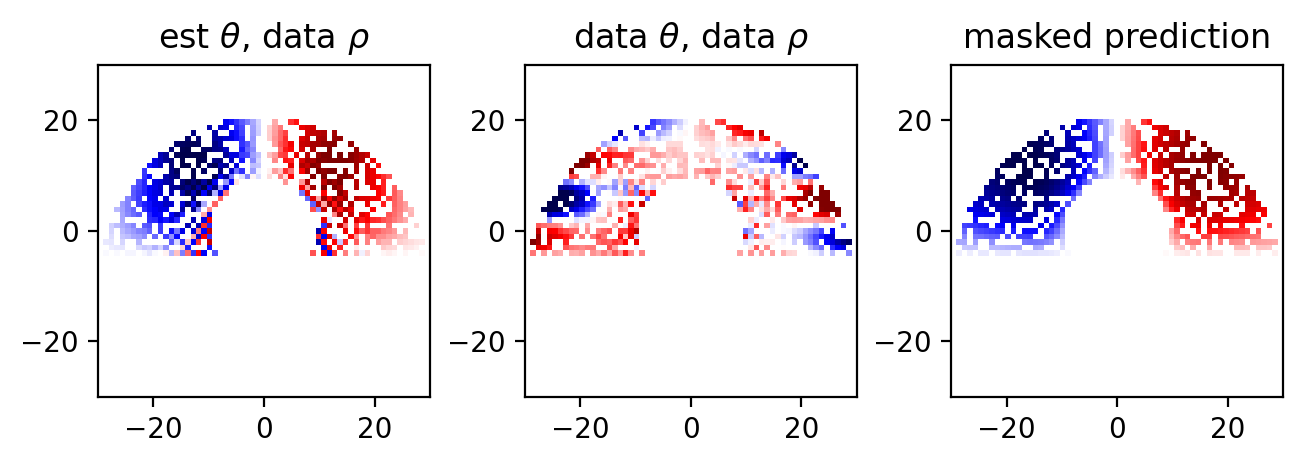

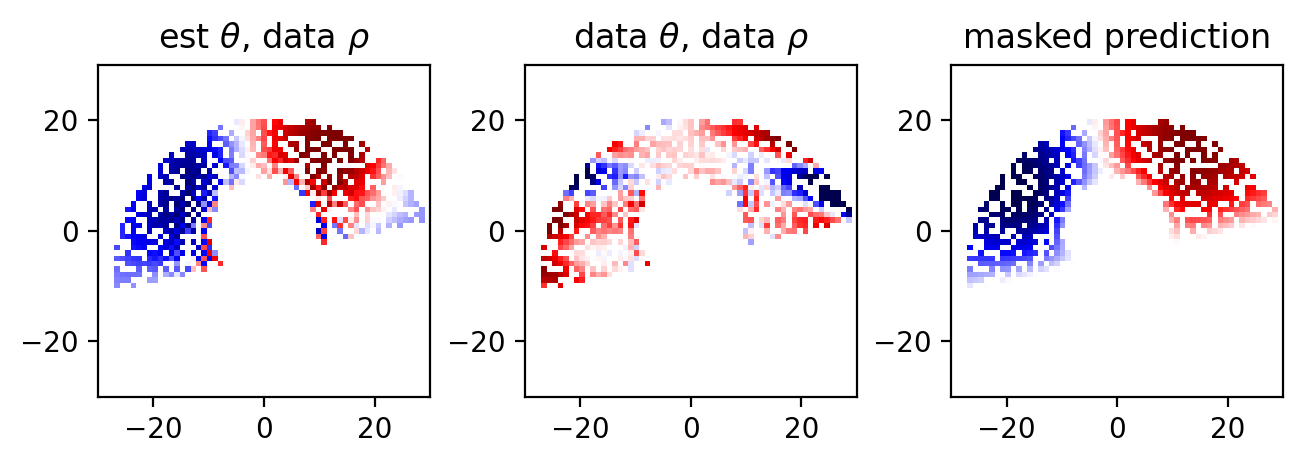

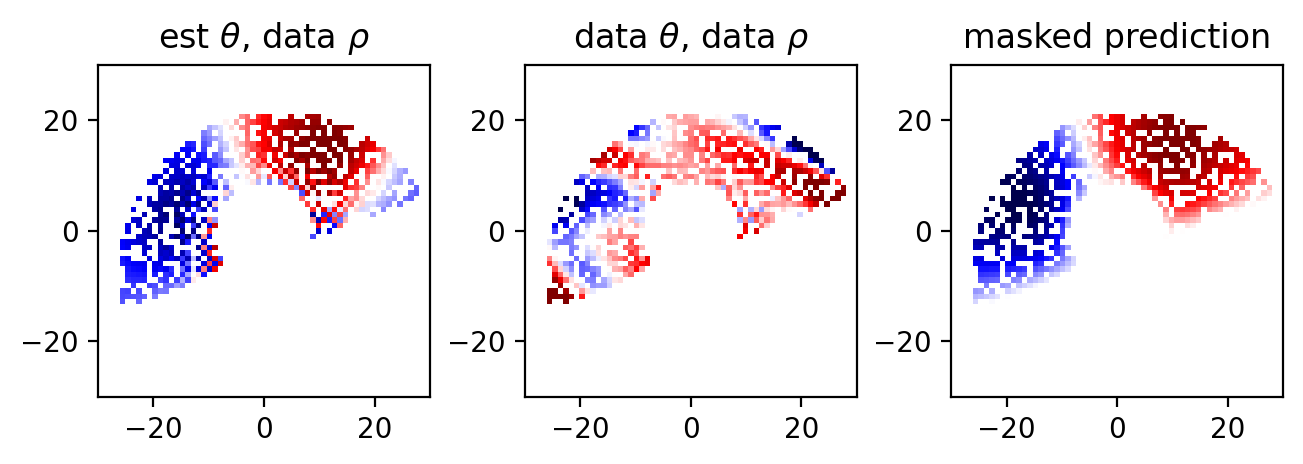

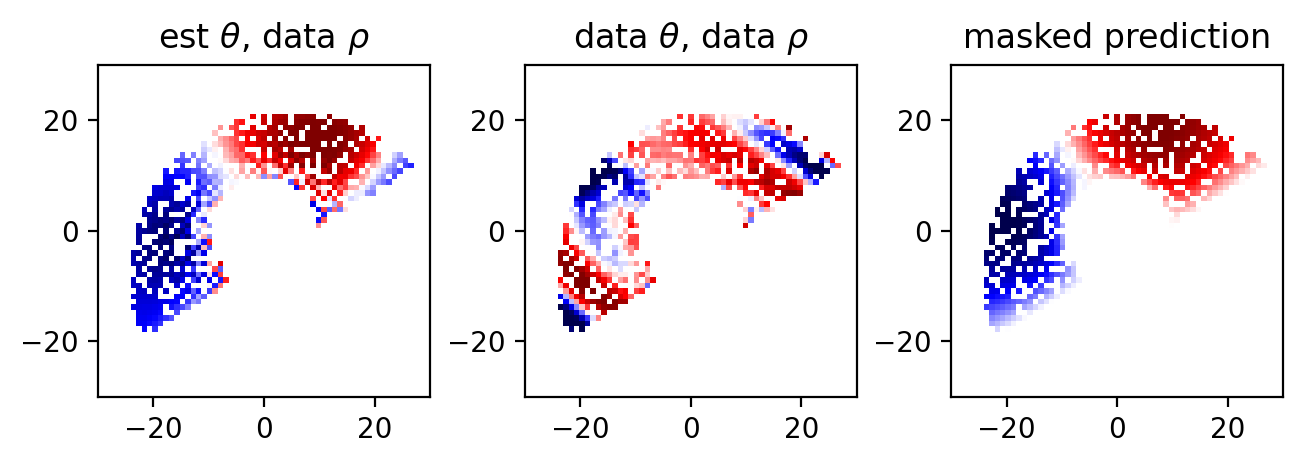

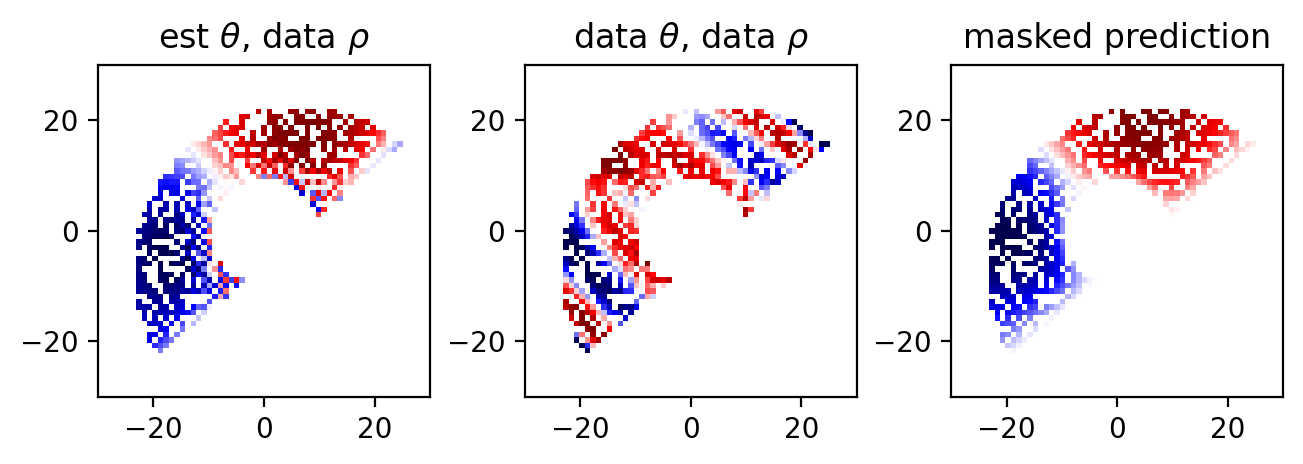

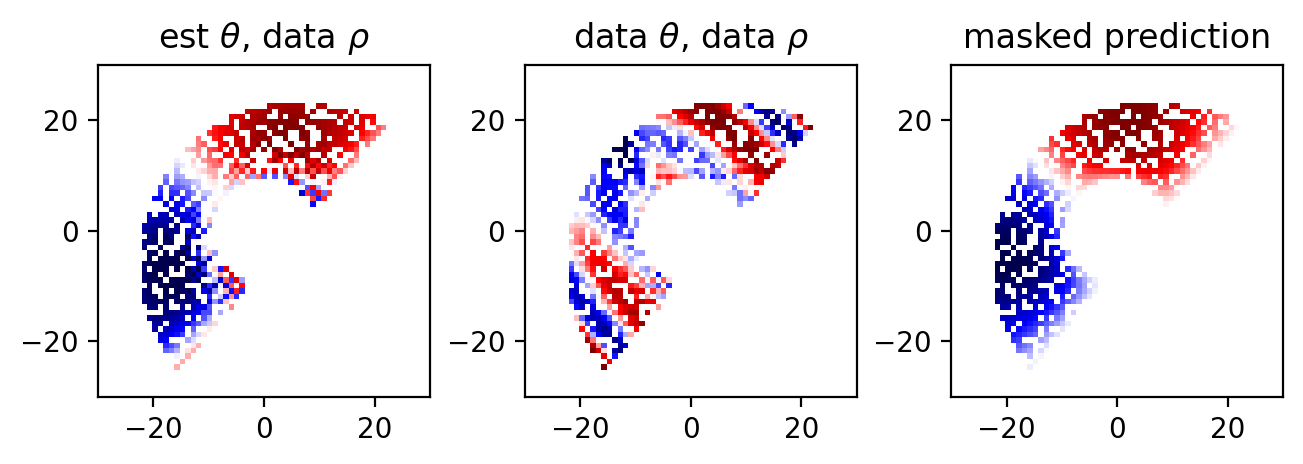

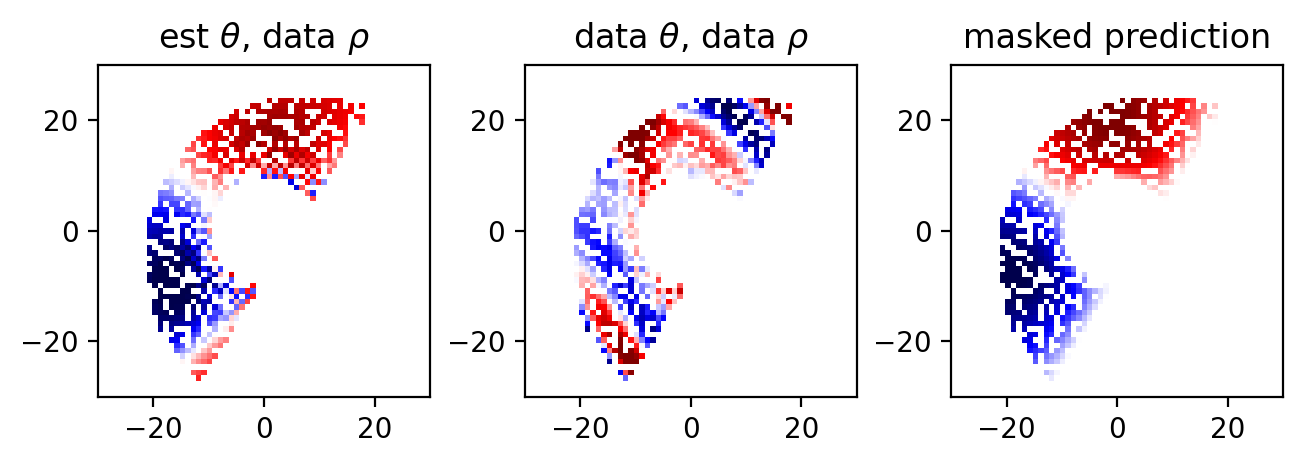

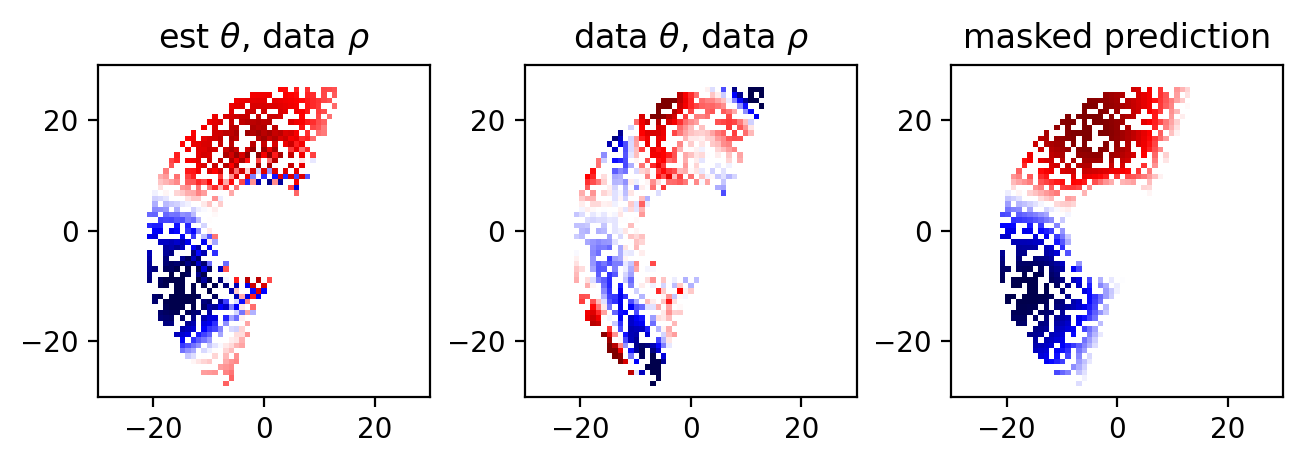

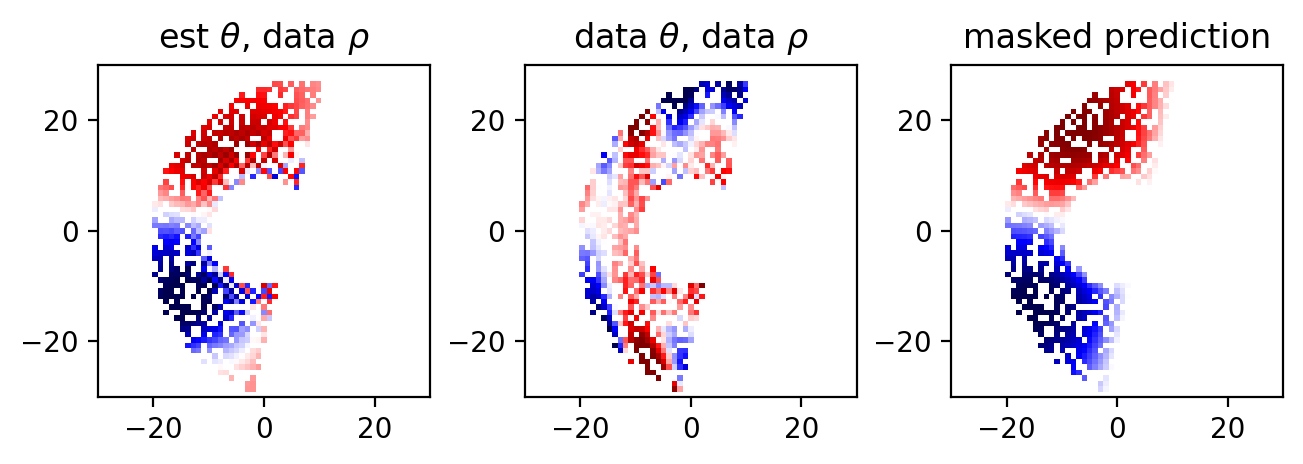

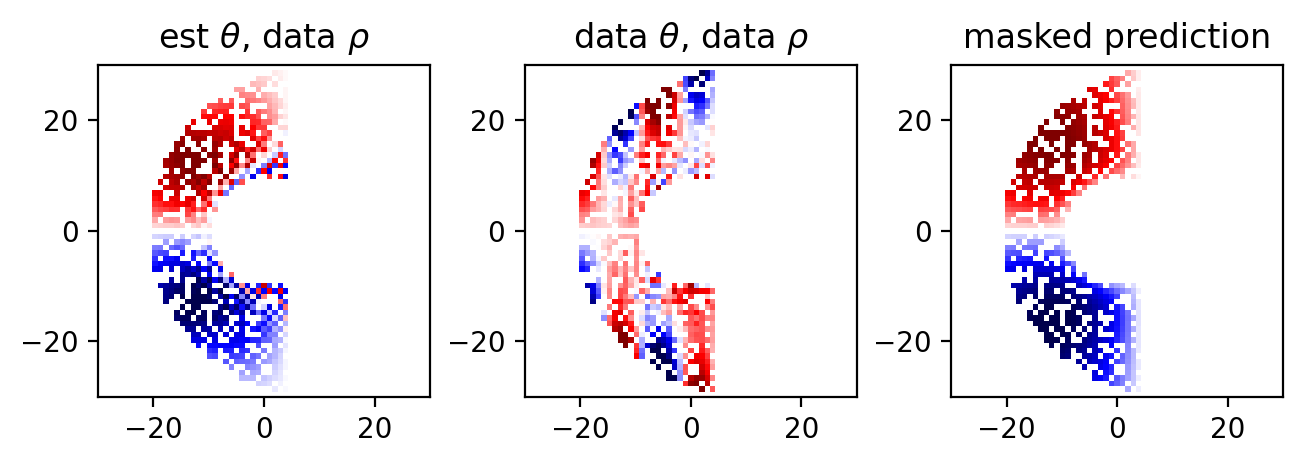

In [9]:
theta_comparison(use_condensate=True,odd=False)

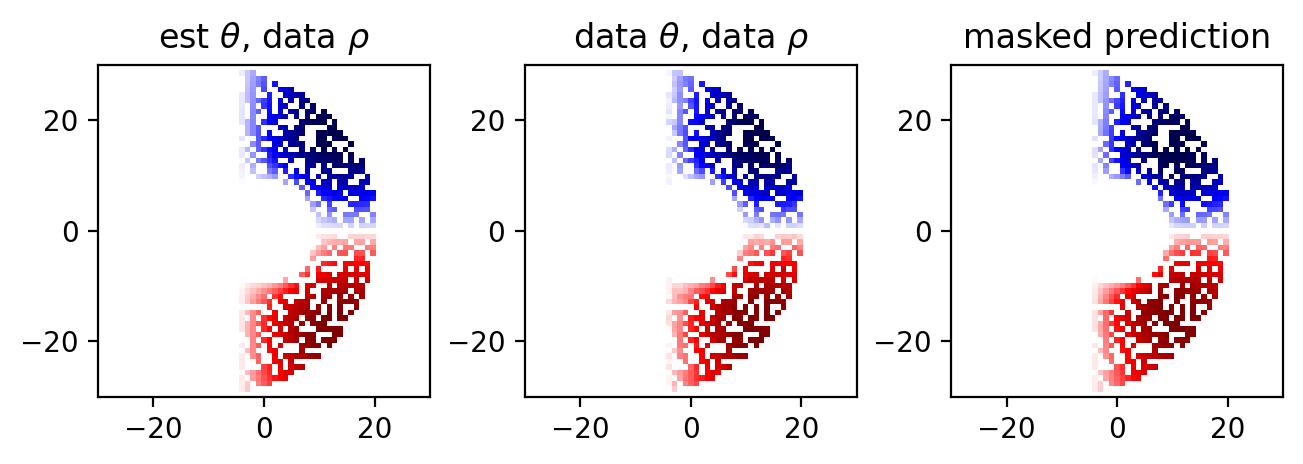

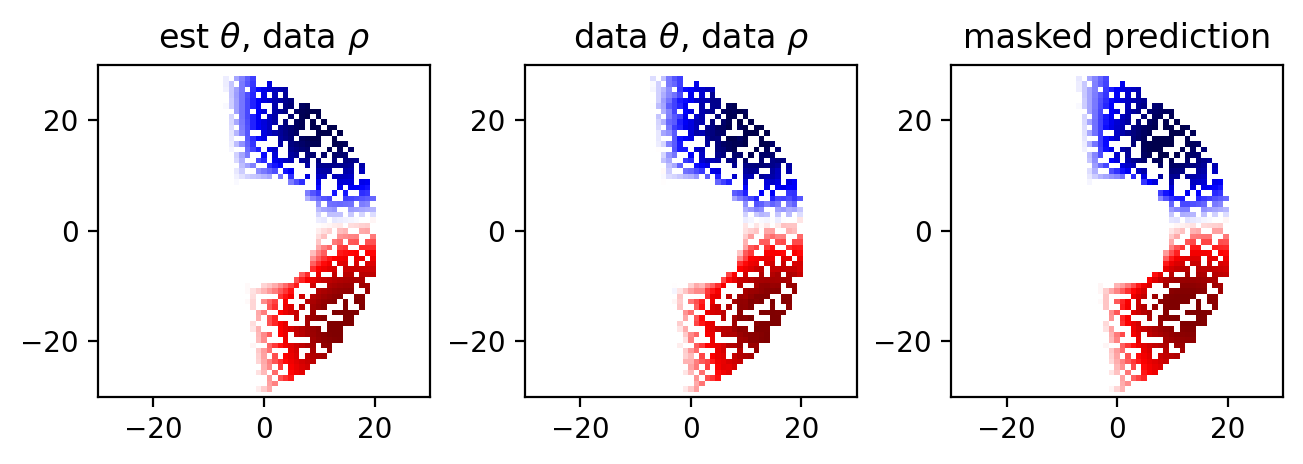

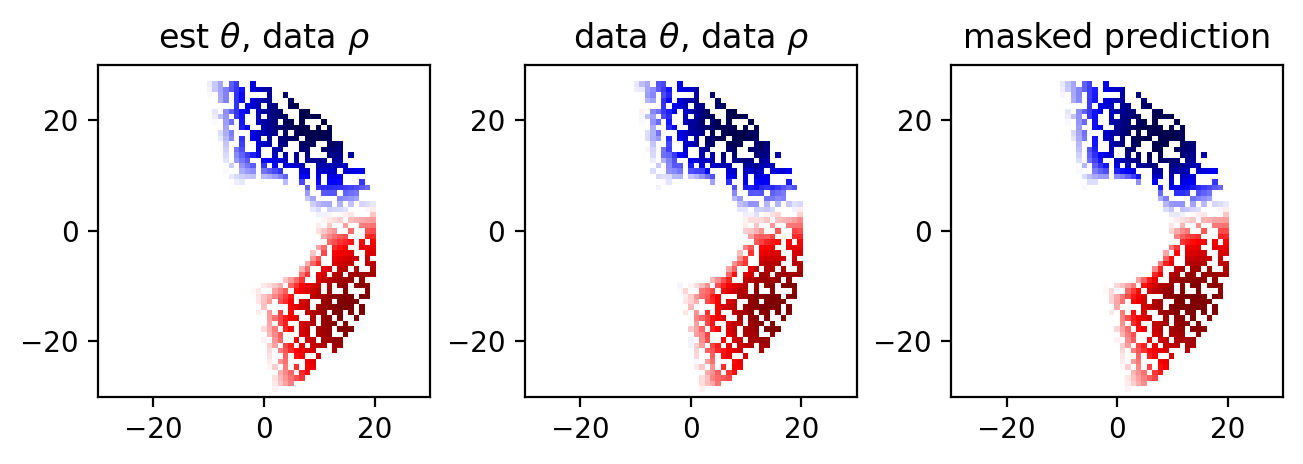

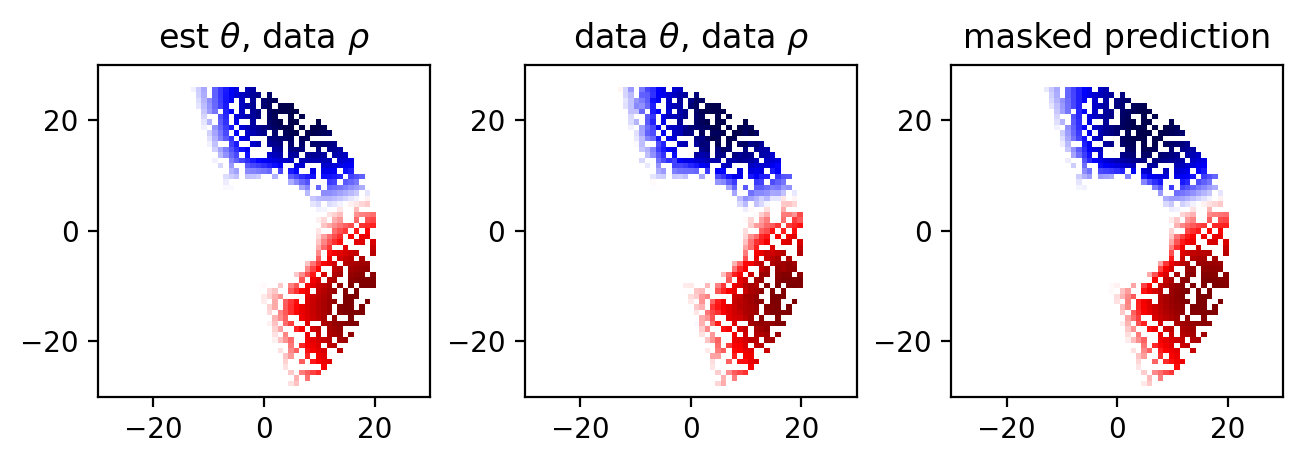

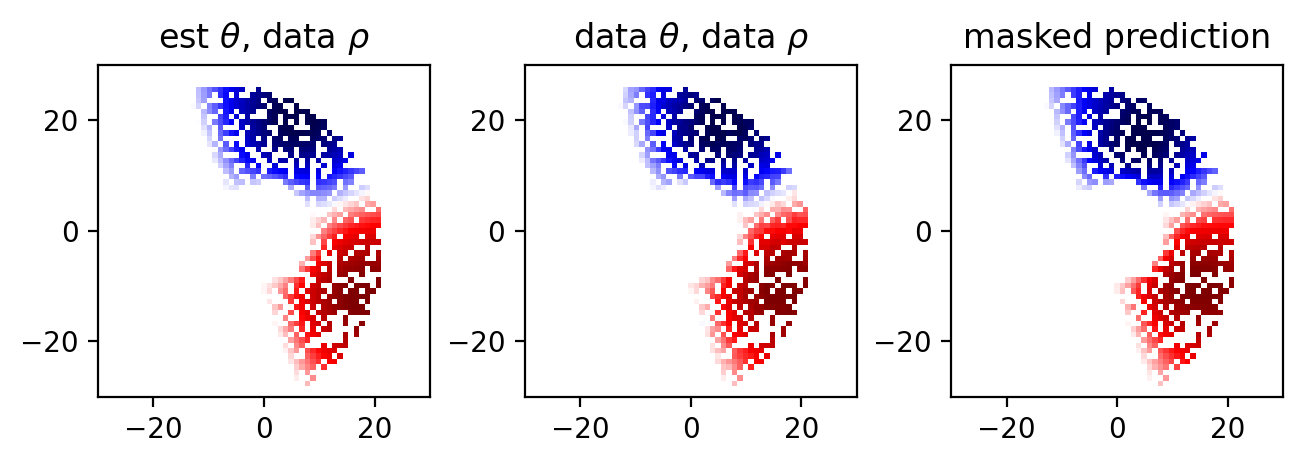

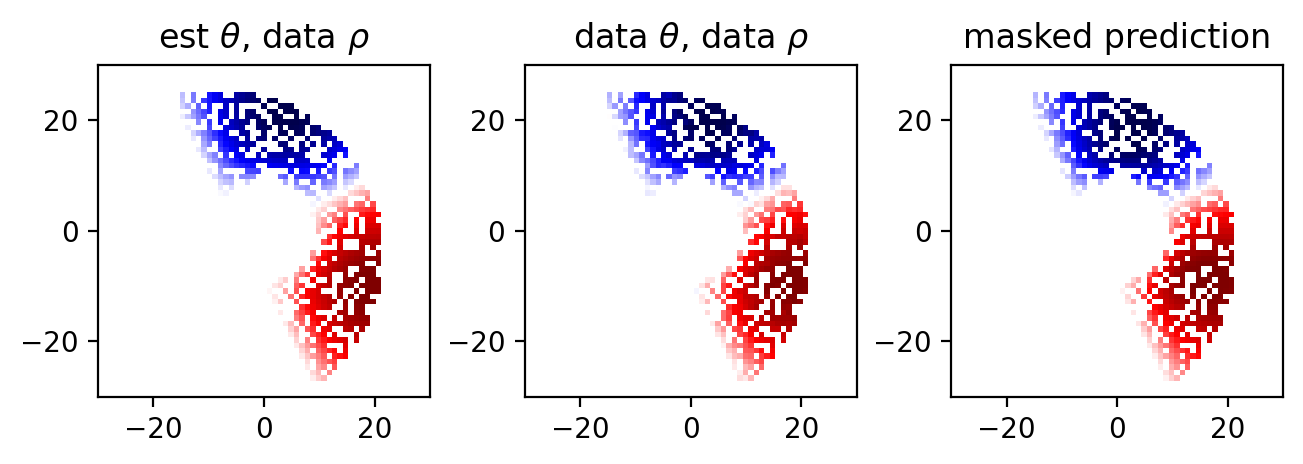

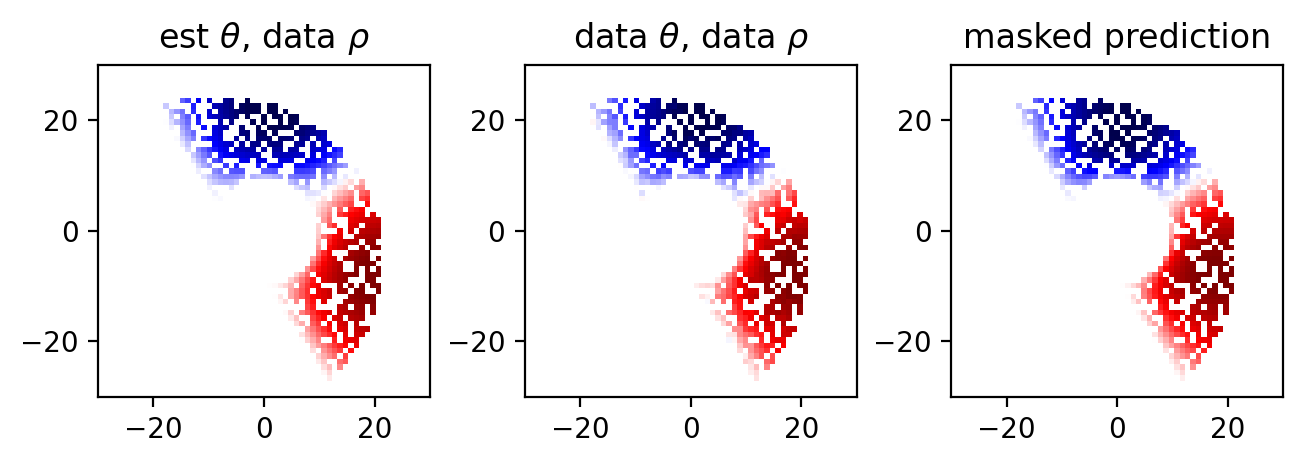

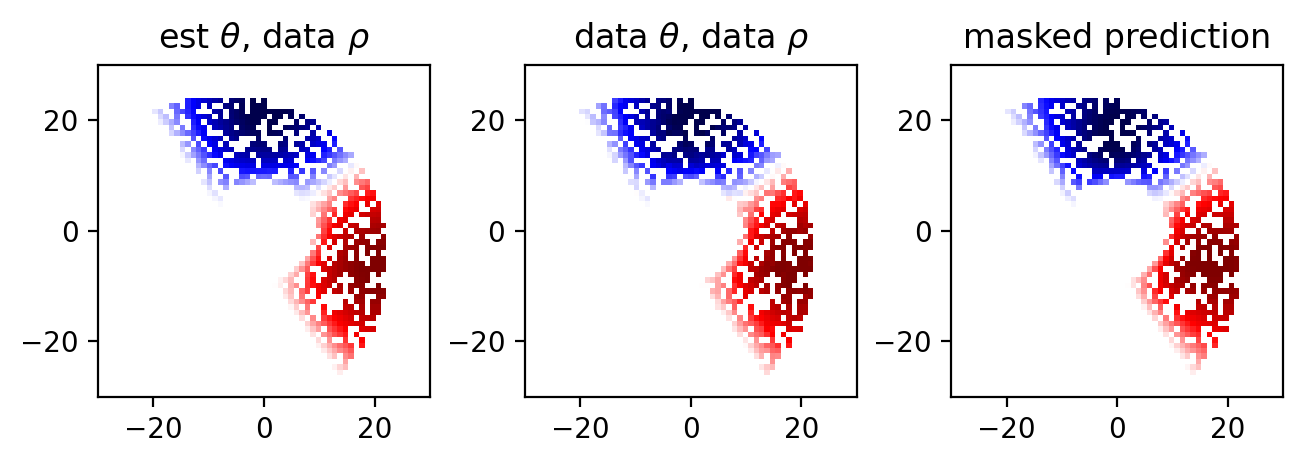

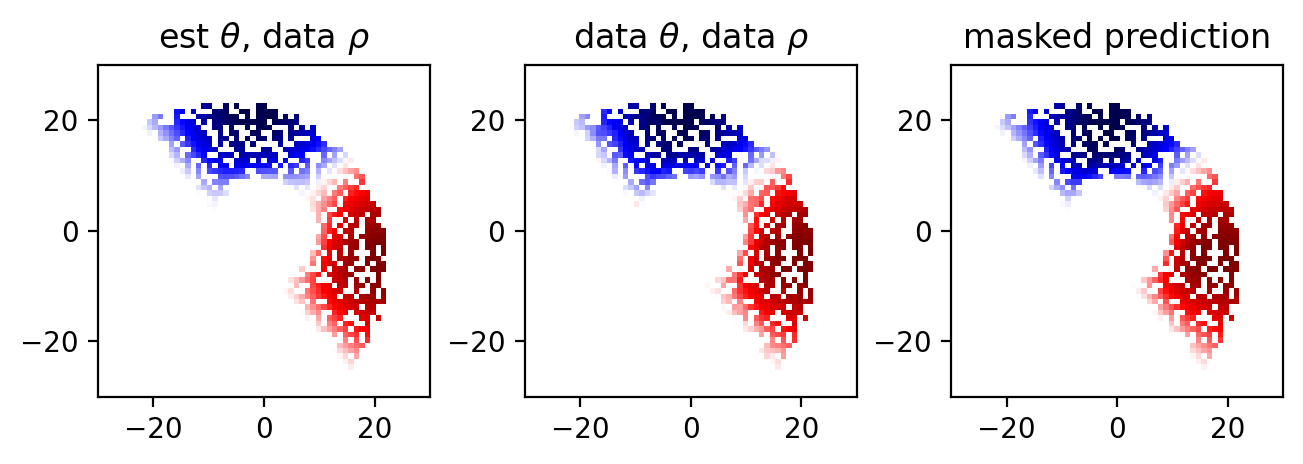

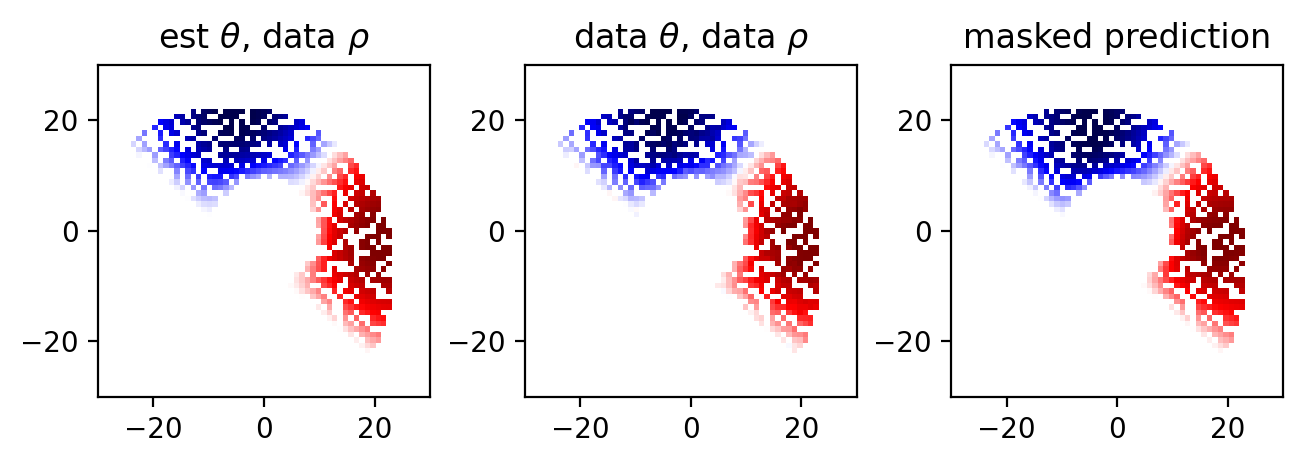

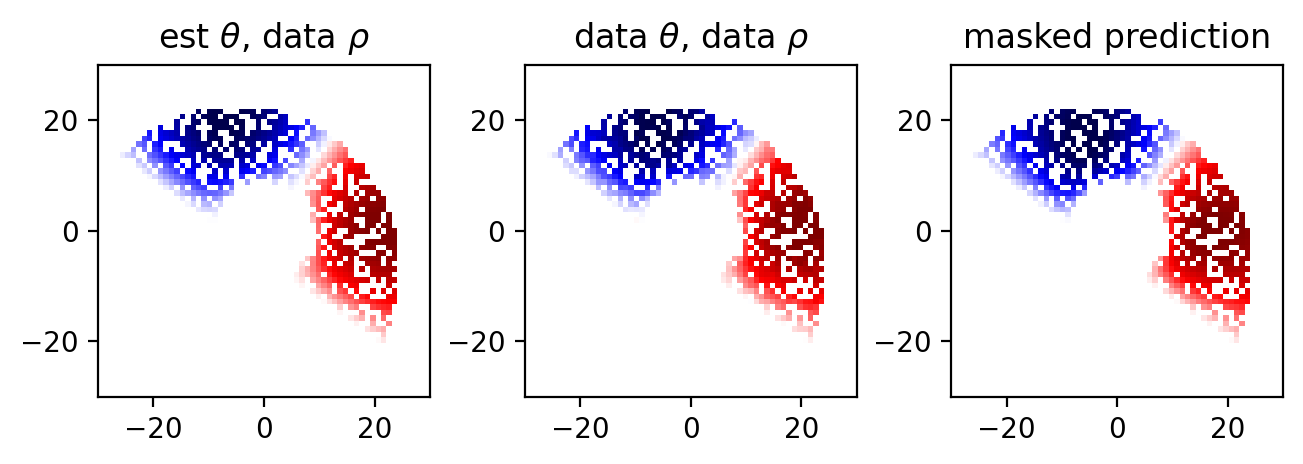

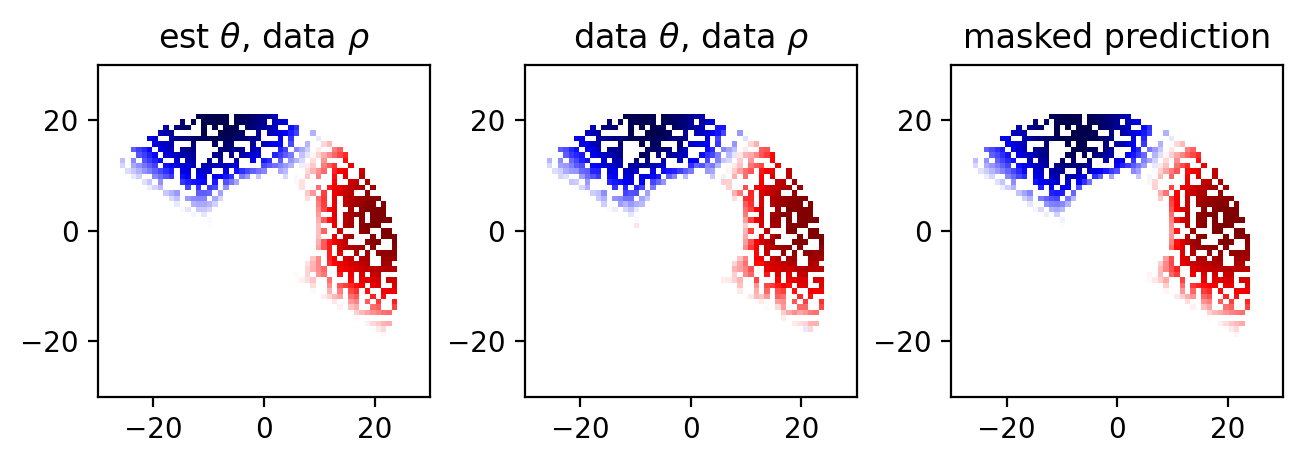

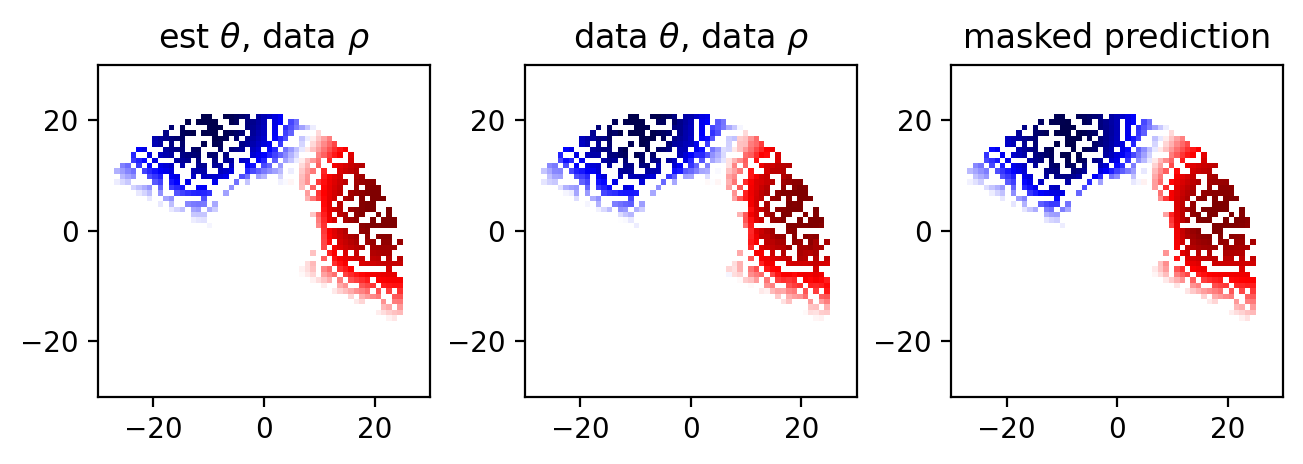

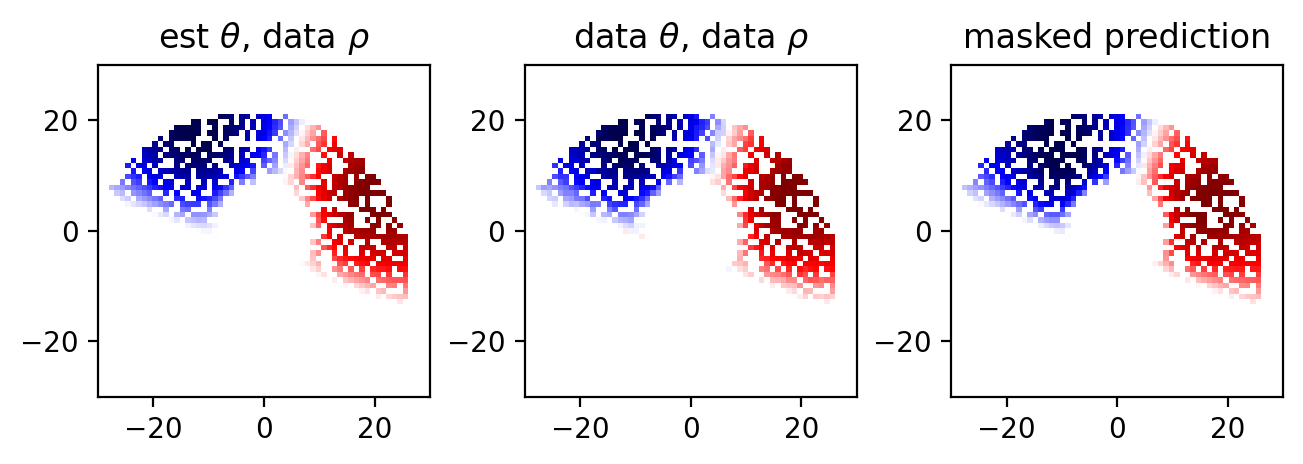

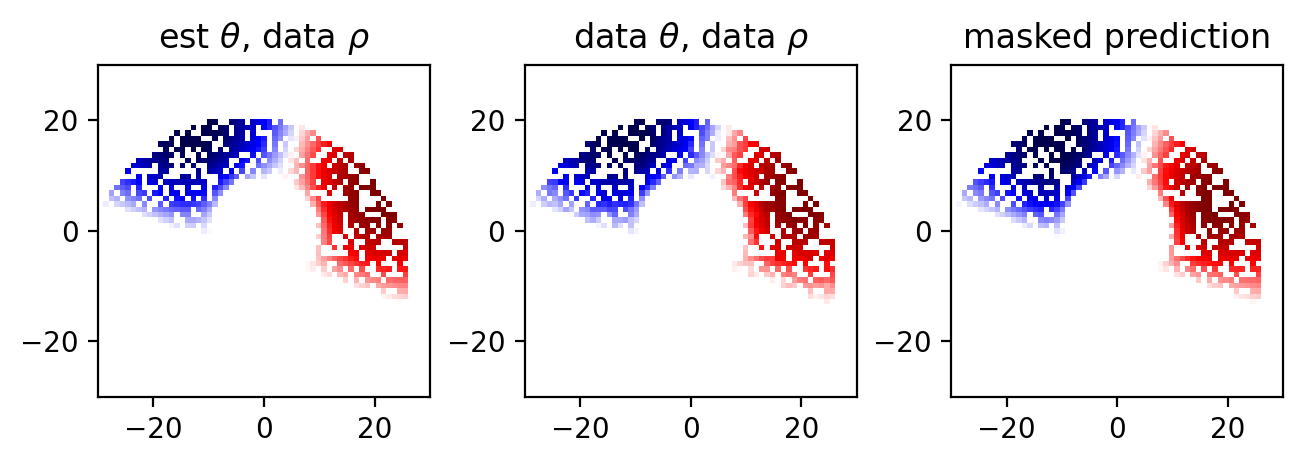

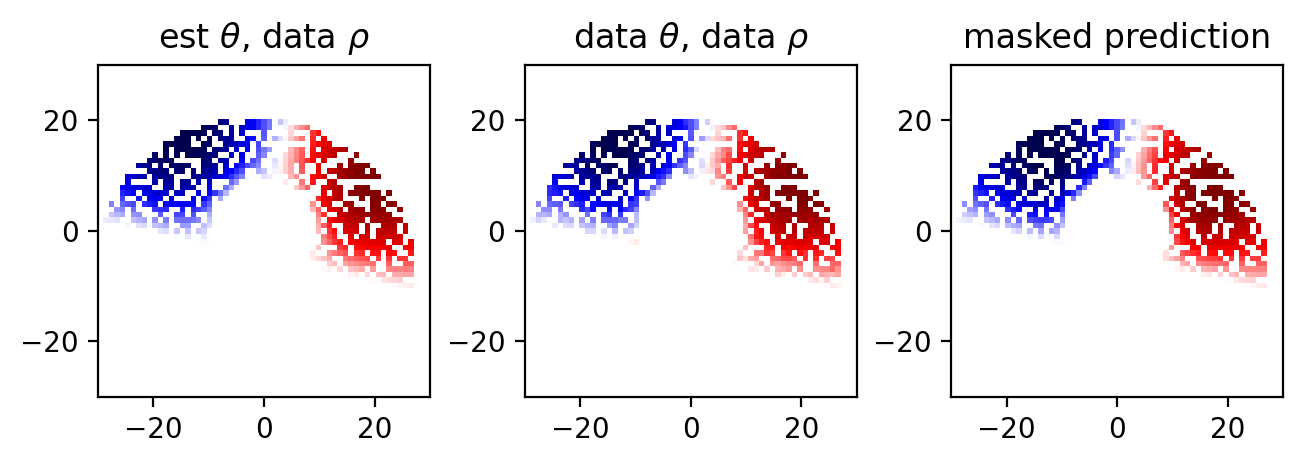

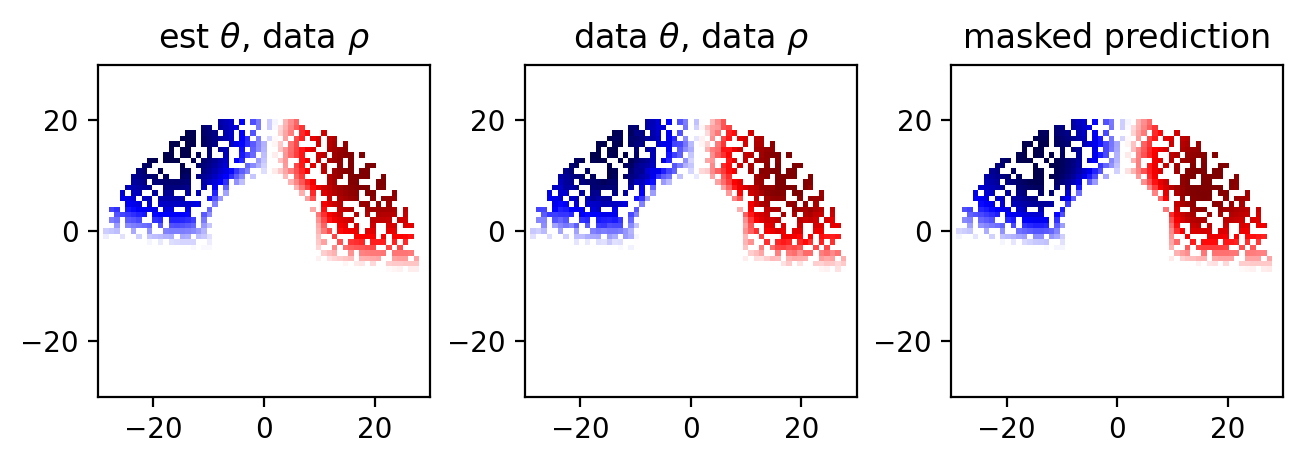

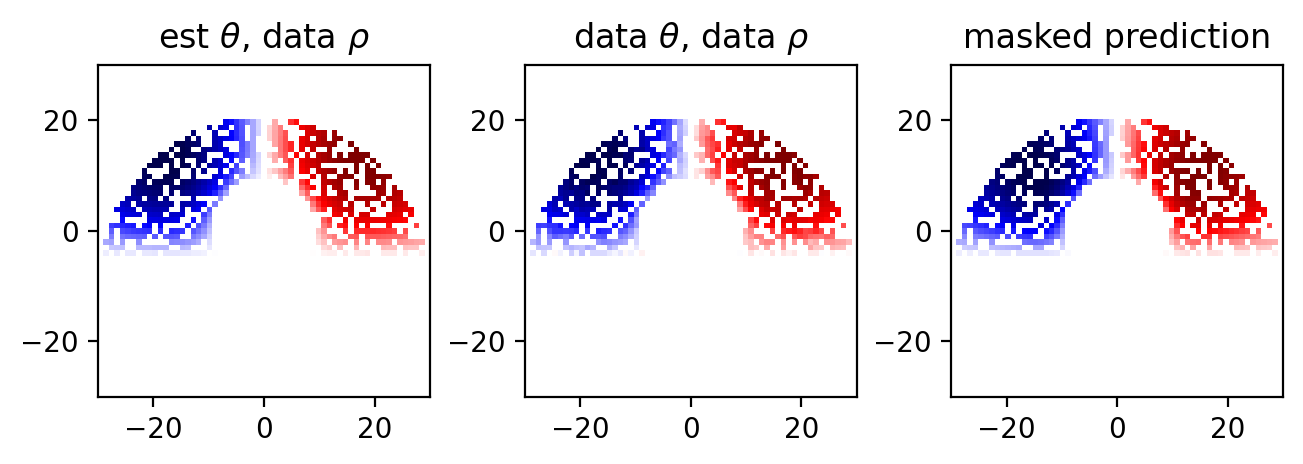

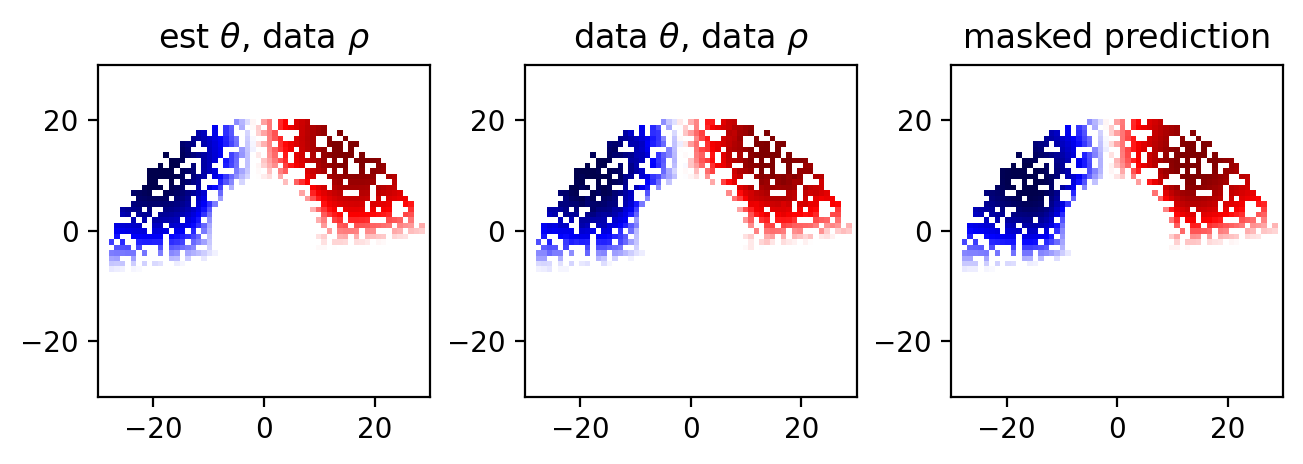

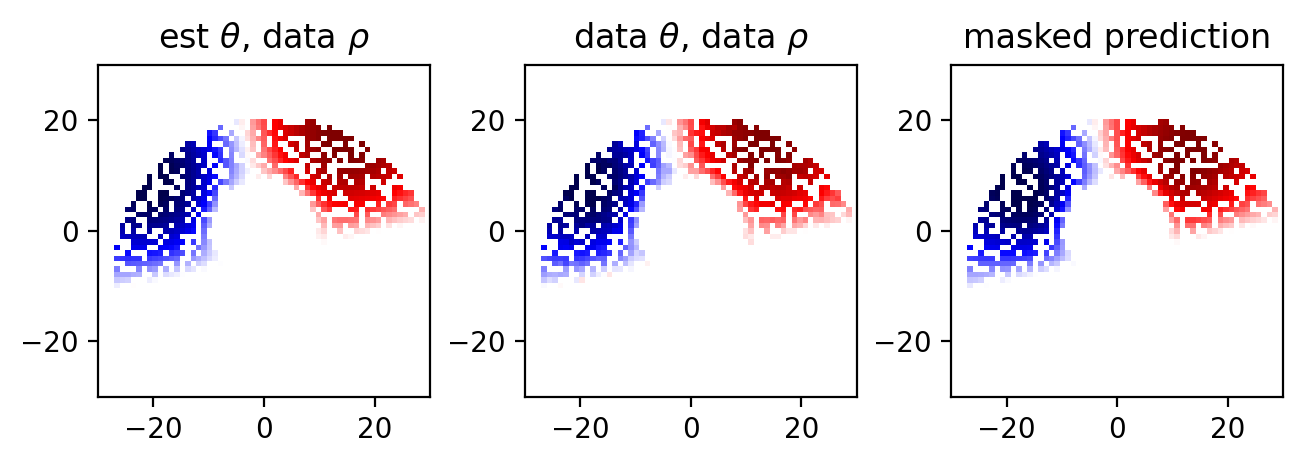

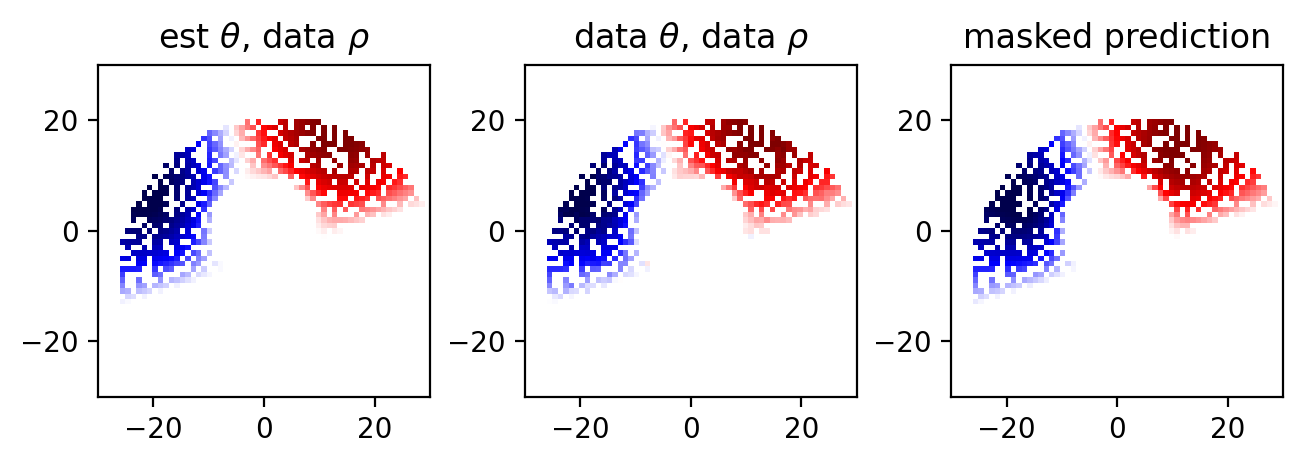

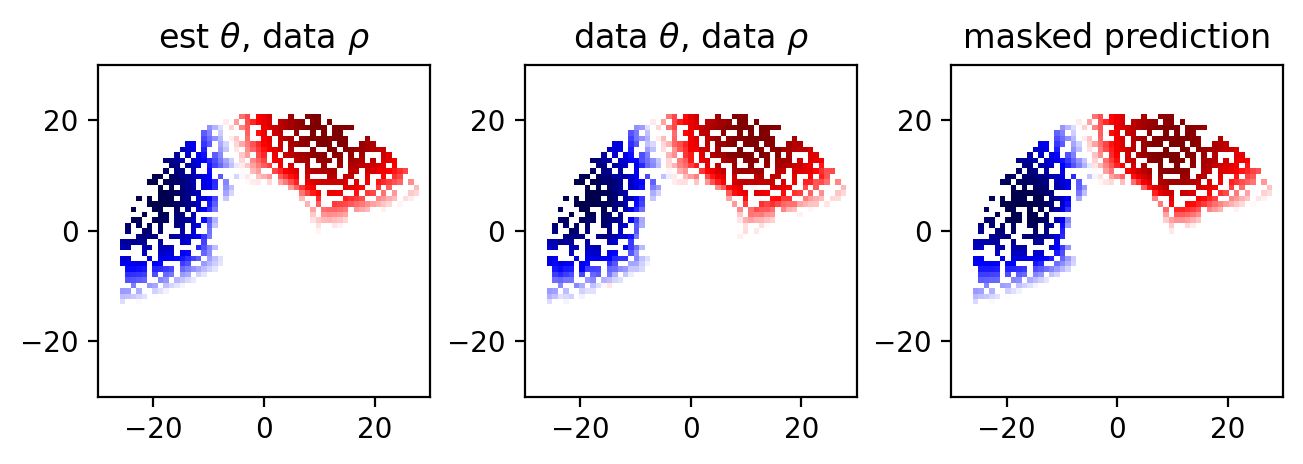

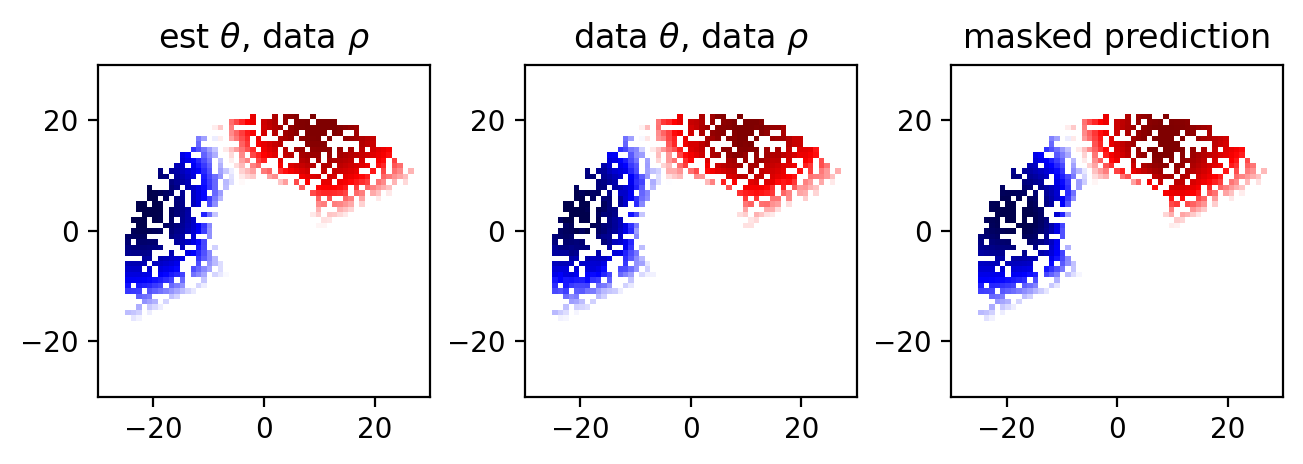

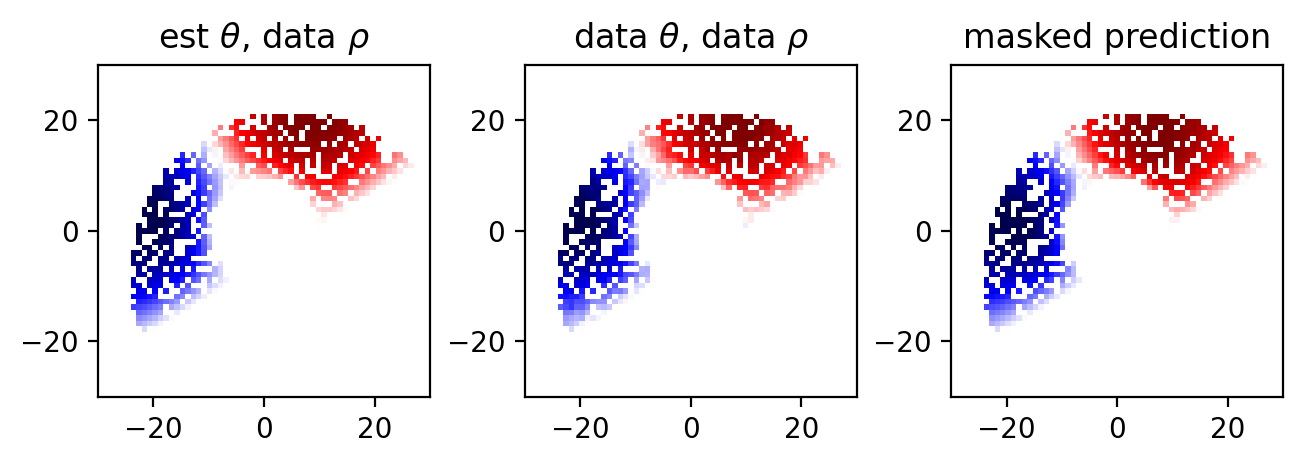

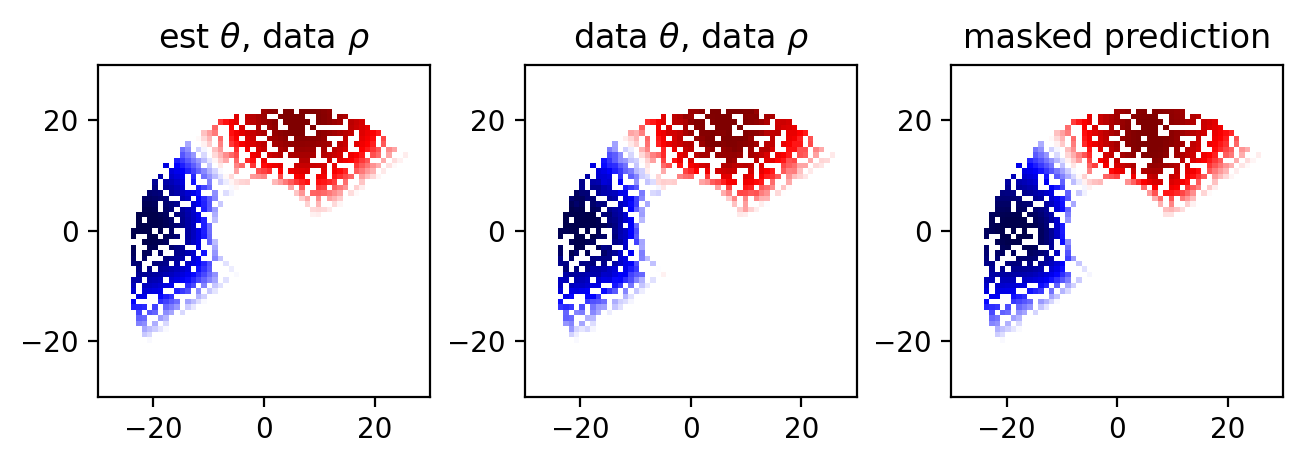

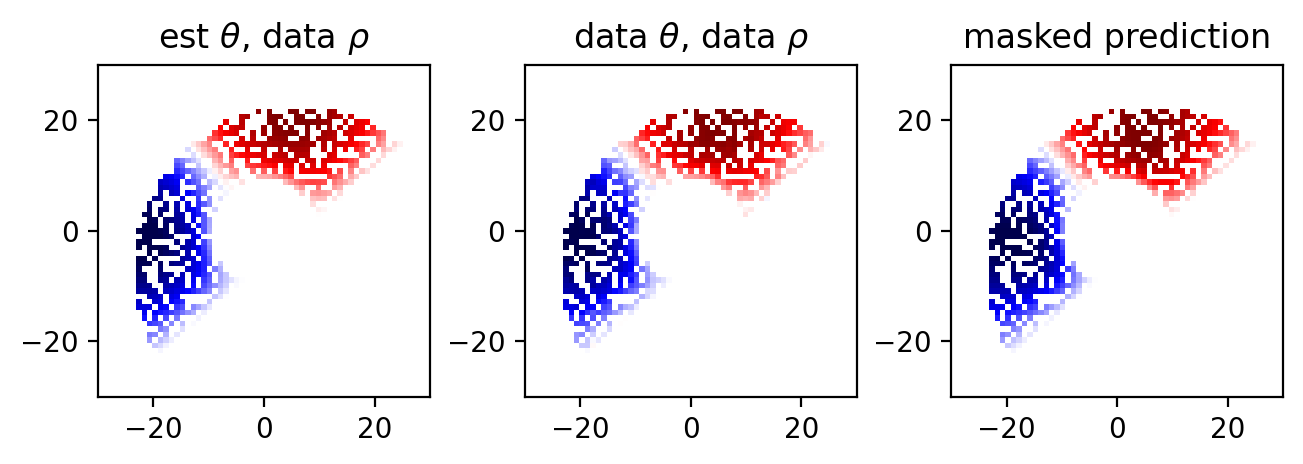

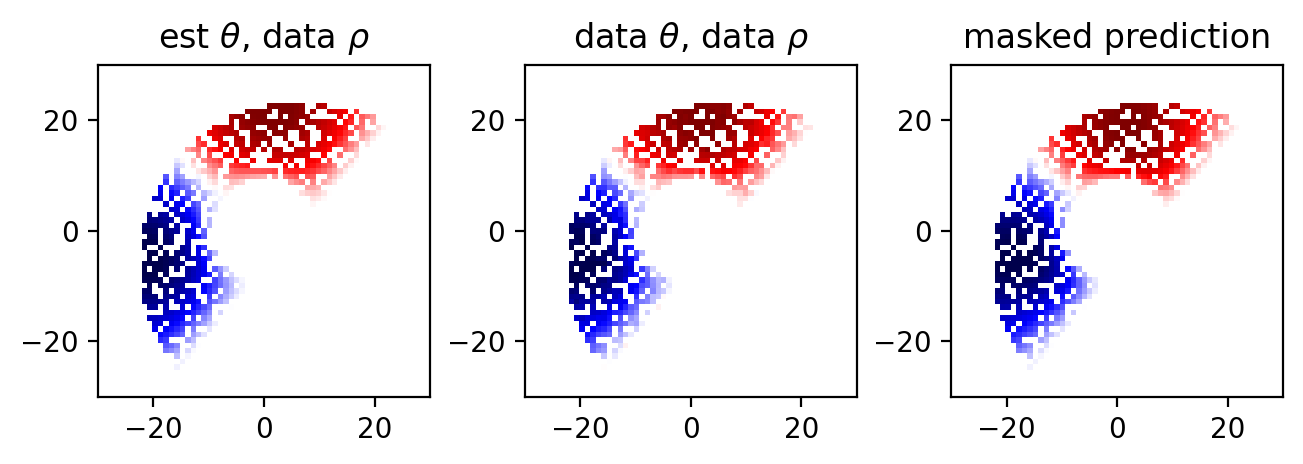

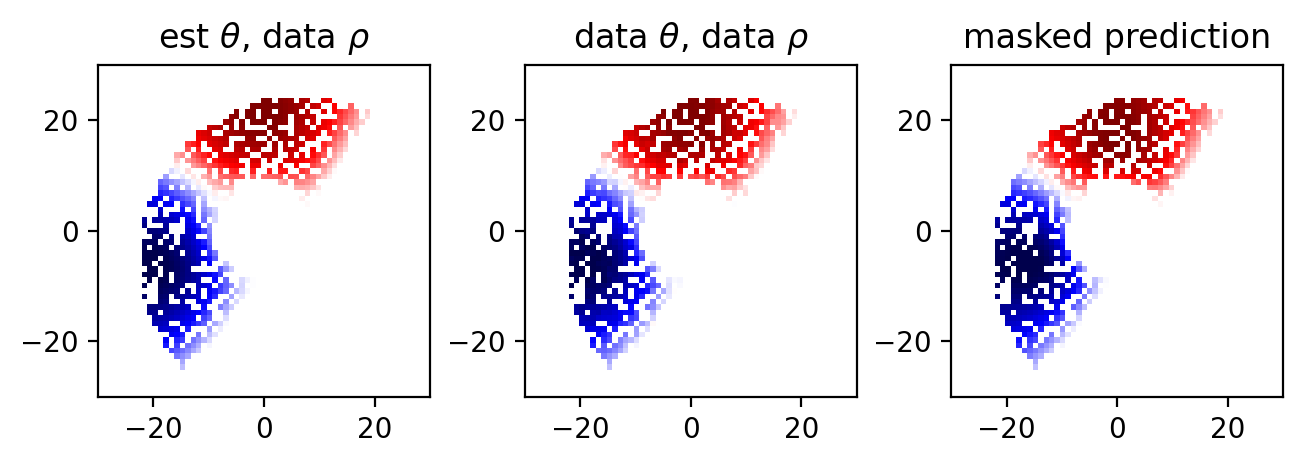

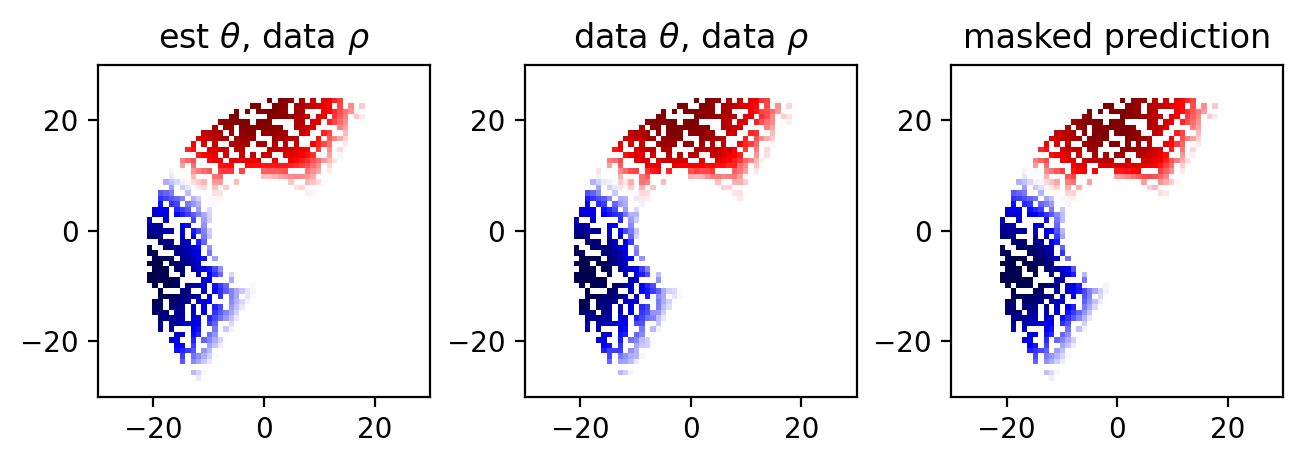

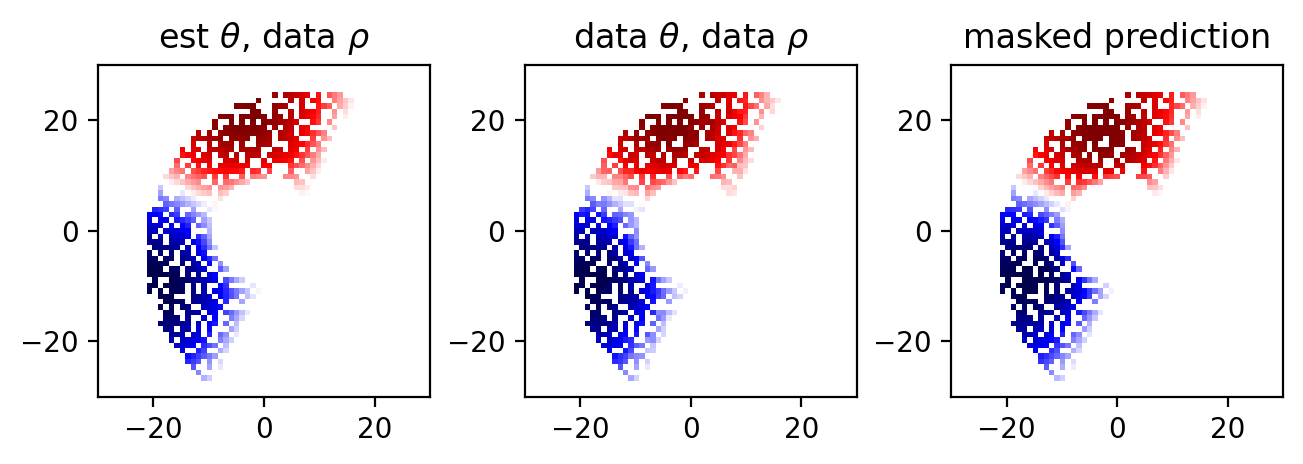

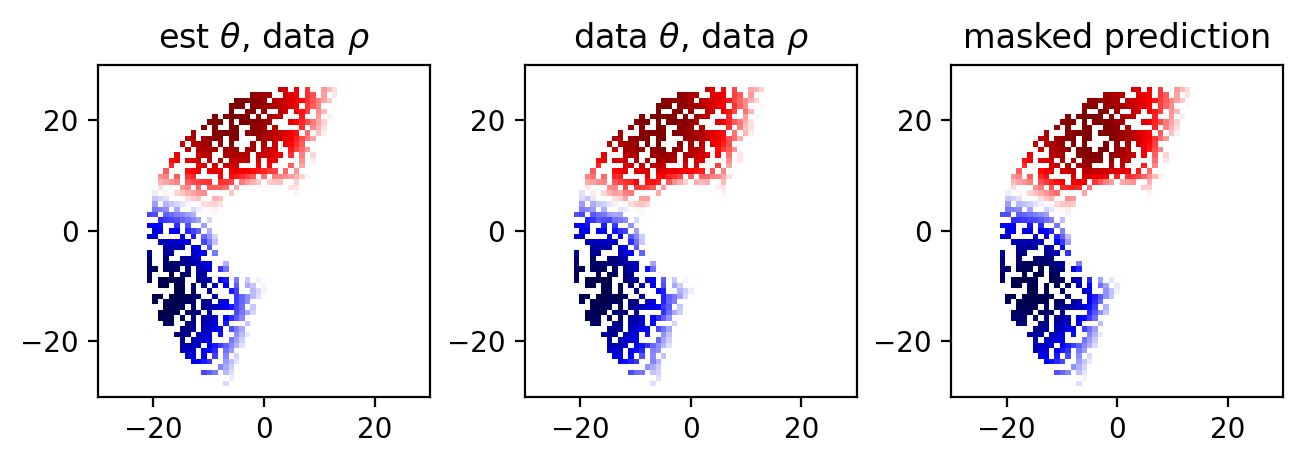

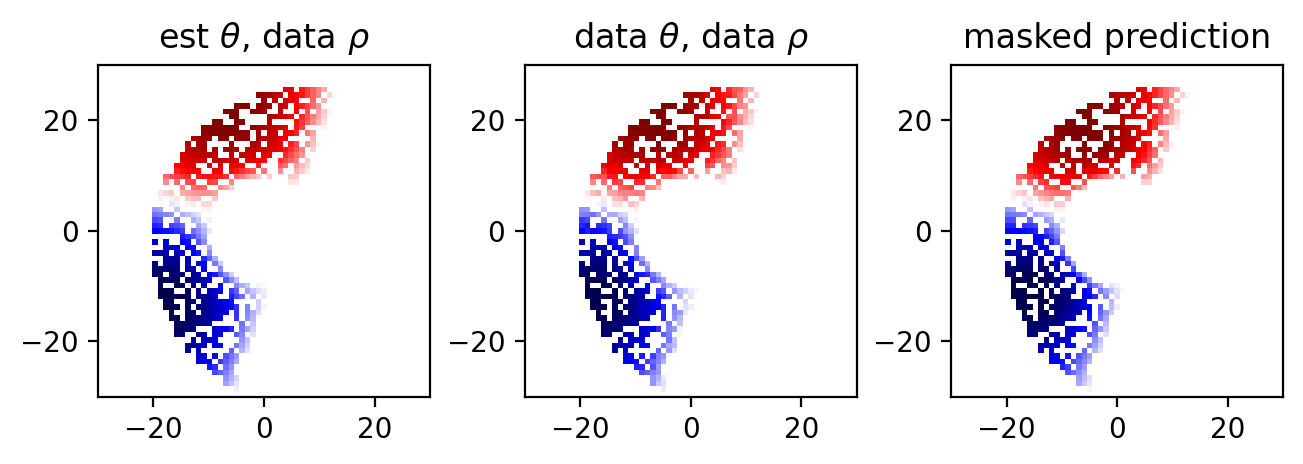

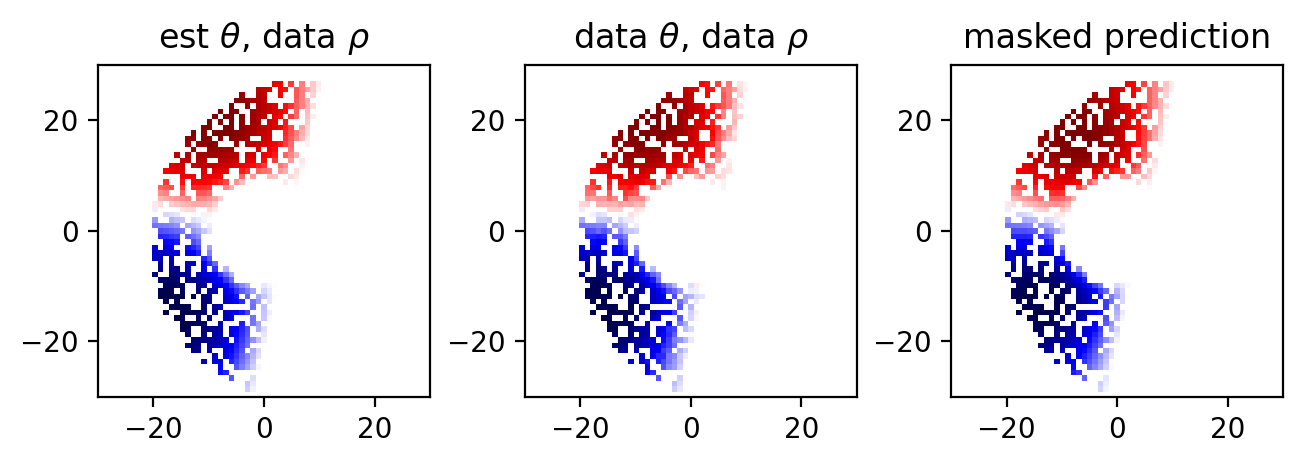

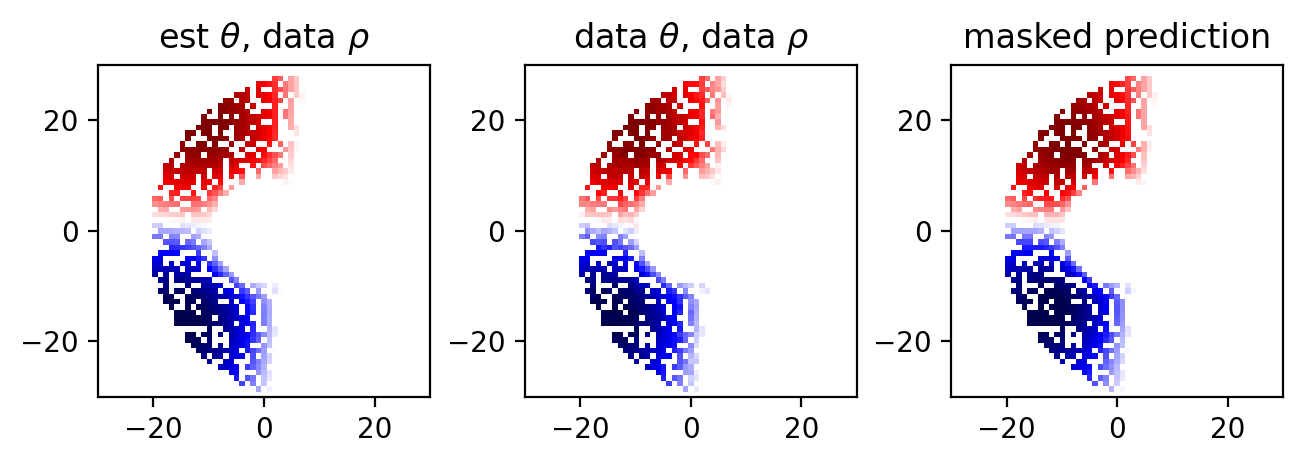

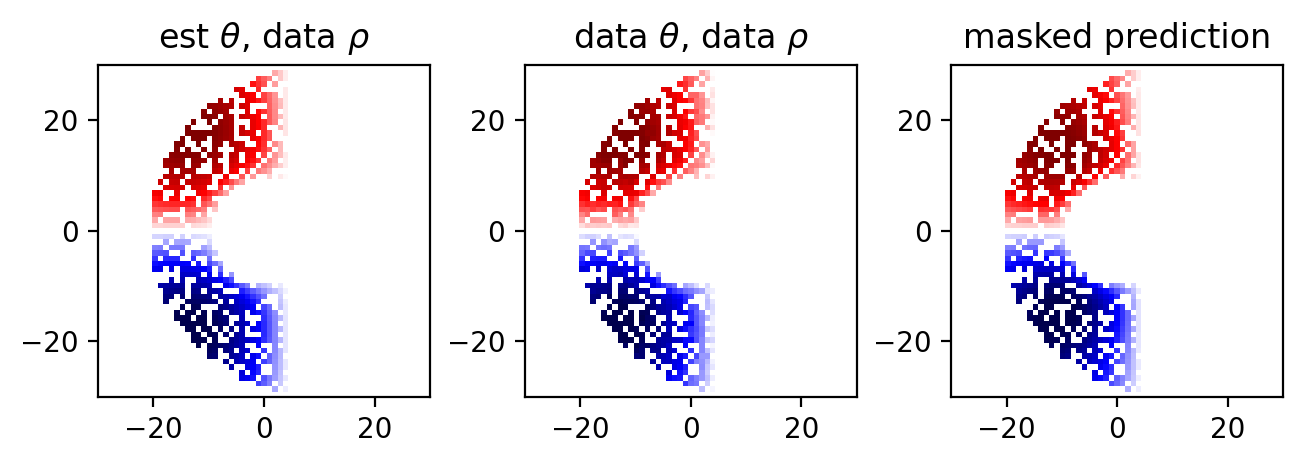

In [10]:
theta_comparison(use_condensate=False)

In [11]:
use_condensate=True # change this to toggle animation below between condensate and normal
odd=False # change this to look at the odd or even (used for patterns)
radius=9 # set radius

In [12]:
## animated version
%matplotlib Tk
if use_condensate:
    data=cos_terms[2:]
    prediction=normal
else:
    data=cos_terms[:2]
    prediction=cond
prediction[data[1]==0]=0

fig,ax=plt.subplots(1,3,layout='constrained');ims=[]
norms=np.linalg.norm(idk,axis=0)
points=idk[:,norms.round()==radius]
points=points.T[np.argsort(np.arctan2(points[1],points[0]))]
coords=(idk+kmax).astype(int)

ax[0].set_title(r'est $\theta$, data $\rho$')
ax[1].set_title(r'data $\theta$, data $\rho$')
ax[2].set_title(r'masked prediction')

for i in range(len(points)):
    if use_condensate:
        if order(points[i])%2==odd:
                continue
        
    grid=np.zeros([n]*2);grid[coords[1],coords[0]]=data[0][order(points[i])]
    if np.all(grid==0):
        continue
    grid[grid==0]=None
    vmax=np.percentile(np.abs(grid)[~np.isnan(grid)],95)
    im0=ax[0].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='seismic',vmin=-vmax,vmax=vmax,animated=True)

    grid=np.zeros([n]*2);grid[coords[1],coords[0]]=data[1][order(points[i])]
    if np.all(grid==0):
        continue
    grid[grid==0]=None
    vmax=np.percentile(np.abs(grid)[~np.isnan(grid)],95)
    im1=ax[1].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='seismic',vmin=-vmax,vmax=vmax,animated=True)

    grid=np.zeros([n]*2);grid[coords[1],coords[0]]=prediction[order(points[i])]
    if np.all(grid==0):
        continue
    grid[grid==0]=None
    vmax=np.percentile(np.abs(grid)[~np.isnan(grid)],95)
    im2=ax[2].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='seismic',vmin=-vmax,vmax=vmax,animated=True)
    
    ims.append([im0,im1,im2])
ani=animation.ArtistAnimation(fig,ims,interval=350,blit=True,repeat=True,repeat_delay=0)
# if use_condensate:
#     if odd:
#         ani.save(f'plots/cond_odd_{radius}.gif')
#     else:
#         ani.save(f'plots/cond_even_{radius}.gif')
# else:
#     if odd:
#         ani.save(f'plots/normal_odd_{radius}.gif')
#     else:
#         ani.save(f'plots/normal_even_{radius}.gif')
plt.show()